<a href="https://colab.research.google.com/github/kachytronico/programacion-ia-colab-labs/blob/main/neumon_ia_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# 📝 Neumon-IA


> Alfredo Ledesma Ruiz



## Supuesto


Un centro sanitario nos ha facilitado dos carpetas que contienes imágenes médicas clasificadas en dos grupos: pacientes sanos (NORMAL) y pacientes con neumonía (PNEUMONIA). Nuestro objetivo será desarrollar un sistema de Inteligencia Artificial capaz de distinguir automáticamente entre ambos casos a partir de las imágenes disponibles.

Para ello, deberemos estudiar la composición del conjunto de datos, preparar correctamente las imágenes y entrenar uno o varios modelos de clasificación. Además, será necesario evaluar cuidadosamente los resultados obtenidos, prestando especial atención a los errores cometidos por el sistema, especialmente aquellos casos en los que una neumonía no sea detectada.

Finalmente, interpretaremos el comportamiento del modelo para comprobar en qué regiones de la imagen basan sus decisiones y valorar si la solución propuesta podría servir como sistema de apoyo en un entorno clínico real.

### Hitos

1. **RA1.** Revisa tamaños, formatos, canales y posibles imágenes corruptas o duplicadas, y actúa acorde.
2. **RA2.** Divide el conjunto de datos en entrenamiento, validación y testeo con una estrategia reproducible y estratificada. Reserva un 10% para testeo y un 10% para validación.
3. **RA4.** Crea un `DataBlock` que permita cargar, redimensionar y normalizar las imágenes correctamente.
4. **RA4.** Entrena un primer modelo *deep* base para clasificar imágenes en NORMAL o PNEUMONIA.
5. **RA4.** Optimiza el modelo anterior con tres técnicas a tu elección (el aumento de datos no cuenta, porque ya lo hemos aplicado en (3)).
6. **RA4.** Entrena un segundo modelo modificando la familia de la arquitectura.
7. **RA4.** Muestra la matriz de confusión del mejor modelo usando el conjunto de testeo y comenta los errores más importantes. Analiza especialmente los falsos negativos y justifica por qué son críticos en este contexto.
8. **RA4.** Aplica técnicas de interpretabilidad visual, como Grad-CAM, para estudiar en qué zonas se fija el modelo.

## Clonar Repo

In [ ]:
!git clone https://github.com/ruescog/datasets

Cloning into 'datasets'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 60 (delta 0), reused 0 (delta 0), pack-reused 59 (from 2)
Receiving objects: 100% (60/60), 401.03 MiB | 71.71 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
!unzip /content/datasets/PIA/2026/ORD1/P2.zip

Archive:  /content/datasets/PIA/2026/ORD1/P2.zip
   creating: NORMAL/
  inflating: NORMAL/IM-0001-0001_aug_1366.jpg  
  inflating: NORMAL/IM-0001-0001_aug_884.jpg  
  inflating: NORMAL/IM-0009-0001.jpeg  
  inflating: NORMAL/IM-0011-0001-0001_aug_2002.jpg  
  inflating: NORMAL/IM-0011-0001-0001_aug_2296.jpg  
  inflating: NORMAL/IM-0011-0001-0001_aug_2434.jpg  
  inflating: NORMAL/IM-0015-0001_aug_1439.jpg  
  inflating: NORMAL/IM-0017-0001.jpeg  
  inflating: NORMAL/IM-0025-0001.jpeg  
  inflating: NORMAL/IM-0027-0001.jpeg  
  inflating: NORMAL/IM-0028-0001_aug_1096.jpg  
  inflating: NORMAL/IM-0029-0001_aug_2253.jpg  
  inflating: NORMAL/IM-0031-0001.jpeg  
  inflating: NORMAL/IM-0033-0001-0002_aug_1127.jpg  
  inflating: NORMAL/IM-0035-0001.jpeg  
  inflating: NORMAL/IM-0036-0001_aug_1854.jpg  
  inflating: NORMAL/IM-0037-0001_aug_903.jpg  
  inflating: NORMAL/IM-0039-0001.jpeg  
  inflating: NORMAL/IM-0045-0001_aug_1644.jpg  
  inflating: NORMAL/IM-0049-0001.jpeg  
  inflating: NOR

---

# Inspección estructural inicial



In [ ]:
import os
from pathlib import Path
from PIL import Image
import pandas as pd
from collections import defaultdict
import random

base_path = Path('/content')
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

resumen_carpetas = []
todas_rutas = []
nombres_archivos = defaultdict(list)

print("=== INSPECCIÓN ESTRUCTURAL DE CARPETAS ===\n")
for root, dirs, files in os.walk(base_path):
    root_path = Path(root)
    # Omitir carpetas del sistema, git o descargas en crudo que no son el dataset extraído
    if any(part in ['sample_data', '.config', '.git', 'datasets'] or part.startswith('.') for part in root_path.parts):
        continue

    imgs = [f for f in files if Path(f).suffix.lower() in IMG_EXTS]
    if imgs:
        resumen_carpetas.append({
            "carpeta": str(root_path.relative_to(base_path)),
            "n_imagenes": len(imgs),
            "ejemplo": str(root_path / imgs[0])
        })
        for img in imgs:
            img_path = root_path / img
            todas_rutas.append(img_path)
            nombres_archivos[img].append(str(img_path))

df_carpetas = pd.DataFrame(resumen_carpetas)
display(df_carpetas)

print("\n=== VERIFICACIÓN DE DUPLICADOS ===")
duplicados = {k: v for k, v in nombres_archivos.items() if len(v) > 1}
print(f"Archivos con el mismo nombre en distintas rutas: {len(duplicados)}")
if duplicados:
    print("Ejemplo de duplicados (primeros 3):")
    for k, v in list(duplicados.items())[:3]:
        print(f" - {k}: {v}")

print("\n=== RESOLUCIONES Y EXTENSIONES POR CLASE (Muestra representativa) ===")
random.seed(33)
muestra_rutas = random.sample(todas_rutas, min(300, len(todas_rutas)))
registros = []

for img_path in muestra_rutas:
    try:
        with Image.open(img_path) as im:
            w, h = im.size
            registros.append({
                "clase_carpeta": img_path.parent.name,
                "ancho": w,
                "alto": h,
                "aspect_ratio": round(w / h, 3),
                "extension": img_path.suffix.lower()
            })
    except Exception:
        pass

df_resoluciones = pd.DataFrame(registros)
if not df_resoluciones.empty:
    display(df_resoluciones.groupby("clase_carpeta")[["ancho", "alto", "aspect_ratio"]].describe())
    print("\nExtensiones detectadas por carpeta:")
    display(pd.crosstab(df_resoluciones["clase_carpeta"], df_resoluciones["extension"]))
else:
    print("No se encontraron imágenes válidas para muestrear.")

=== INSPECCIÓN ESTRUCTURAL DE CARPETAS ===



,carpeta,n_imagenes,ejemplo
0,PNEUMONIA,200,/content/PNEUMONIA/person173_bacteria_829.jpeg
1,NORMAL,200,/content/NORMAL/IM-0393-0001_aug_1460.jpg



=== VERIFICACIÓN DE DUPLICADOS ===
Archivos con el mismo nombre en distintas rutas: 0

=== RESOLUCIONES Y EXTENSIONES POR CLASE (Muestra representativa) ===


ancho                                                          \
               count         mean         std    min     25%     50%     75%   
clase_carpeta                                                                  
NORMAL         157.0  1730.630573  283.966712  994.0  1542.0  1744.0  1848.0   
PNEUMONIA      143.0  1175.776224  255.789290  570.0   992.0  1144.0  1272.0   

                        alto               ...                 aspect_ratio  \
                  max  count         mean  ...     75%     max        count   
clase_carpeta                              ...                                
NORMAL         2746.0  157.0  1404.490446  ...  1558.0  2458.0        157.0   
PNEUMONIA      2064.0  143.0   808.916084  ...   956.0  1752.0        143.0   

                                                                        
                   mean       std    min     25%    50%     75%    max  
clase_carpeta                                                           
NORMAL         1.258586  0.172282  1.007  1.1430  1.225  1.3220  2.034  
PNEUMONIA      1.504413  0.217357  0.991  1.3515  1.480  1.6515  2.174  

[2 rows x 24 columns]


Extensiones detectadas por carpeta:


extension,.jpeg,.jpg
clase_carpeta,,
NORMAL,66,91
PNEUMONIA,143,0


## Decisiones Previas

- **Tarea y métrica**: Clasificación binaria de imágenes médicas. Tras la limpieza del Hito 1 el dataset queda desbalanceado (78 NORMAL vs 200 PNEUMONIA), por lo que la métrica principal pasa a ser **F1 weighted**; el *accuracy* se mantiene como referencia secundaria. El recall de la clase PNEUMONIA será el indicador clínico clave (minimizar falsos negativos).
- **Patrón de validación**: División física de las imágenes en carpetas de entrenamiento (80%), validación (10%) y testeo (10%), utilizando una semilla fija (`random_seed = 33`) para garantizar la reproducibilidad.
- **Riesgos de leakage y control**: Para evitar la contaminación cruzada, verificaremos que no haya imágenes compartidas entre los conjuntos tras la división. Además, cualquier transformación aleatoria (aumento de datos) se aplicará de forma exclusiva al conjunto de entrenamiento.
- **Estado del dataset tras el Hito 1**: 278 imágenes (78 NORMAL, 200 PNEUMONIA). Todas en escala de grises (con 6 PNEUMONIA en RGB anecdóticas), todas `.jpeg`, sin imágenes corruptas y sin imágenes pre-aumentadas. Persiste un sesgo de tamaño/proporción entre clases que se neutralizará al redimensionar en el Hito 3.
- **Clases y contexto médico**: Las categorías son `NORMAL` y `PNEUMONIA`. Se identifica `NORMAL` como la clase sana.
- **Decisiones técnicas diferidas**: El tamaño exacto de redimensionado para el `DataBlock` (Hito 3), las tres técnicas específicas para mitigar el sobreajuste (Hito 5) y la arquitectura alternativa (Hito 6) se determinarán al llegar a dichos puntos.
- **Estado activo inicial**: Las imágenes se encuentran en las carpetas originales dentro del entorno.
- **Conjunto de testeo**: El 10% de testeo quedará completamente aislado desde el principio y solo se evaluará una única vez en el Hito 7 para generar la matriz de confusión final.

### Riesgos adicionales detectados en la inspección inicial

Al revisar los datos extraídos, he detectado tres factores de riesgo importantes:

1. **Mezcla de formatos**: La clase `NORMAL` combina imágenes `.jpeg` y `.jpg` (66 y 91, respectivamente), mientras que `PNEUMONIA` solo contiene `.jpeg` (143). Esto sugiere que las imágenes sanas provienen de fuentes distintas.
2. **Diferencias de resolución y proporción**: Las imágenes de `NORMAL` son notablemente más grandes (~1730 x 1404 px, proporción ~1.26) que las de `PNEUMONIA` (~1175 x 808 px, proporción ~1.50). El modelo podría usar el tamaño o la forma como un atajo para clasificar, en lugar de fijarse en la patología real.
3. **Imágenes pre-aumentadas**: Varios archivos de la clase `NORMAL` incluyen la etiqueta `_aug_` en su nombre (por ejemplo, `IM-0393-0001_aug_1460.jpg`). Esto indica que ya han sufrido aumento de datos artificial. Por tanto, existen casi-duplicados que provienen de una misma imagen original. Tendremos que revisar esto con cuidado en el Hito 1 y aislar los grupos al dividir el dataset en el Hito 2 para no contaminar validación y test con variantes de la misma imagen (leakage).

- **Splits pequeños tras la limpieza**: con 278 imágenes, el 10% de test ronda las 28 imágenes (≈8 NORMAL). Cada error pesará mucho en las métricas; lo tendré presente al interpretar la matriz de confusión del Hito 7.

# Hito 1 — Revisar tamaños, formatos, canales y duplicados

El enunciado pide revisar tamaños, formatos, canales y posibles imágenes corruptas o duplicadas, y actuar en consecuencia. Antes de eliminar o modificar nada, hago primero un diagnóstico completo de las dos carpetas. Con las cifras delante decidiré qué tratamiento aplicar.

In [ ]:
# Hito 1A — Diagnóstico estructural sin modificar archivos
import re
from pathlib import Path
from PIL import Image
import pandas as pd
from fastai.vision.all import get_image_files, verify_images, parent_label

# Rutas activas según Fase A
path_normal = Path('/content/NORMAL')         # CAMBIAR si la raíz cambia
path_pneumonia = Path('/content/PNEUMONIA')   # CAMBIAR si la raíz cambia

# 1. Listado completo
todas = get_image_files(path_normal) + get_image_files(path_pneumonia)
print(f"Total imágenes encontradas: {len(todas)}")

# 2. Detección oficial de corruptas con FastAI
corruptas = verify_images(todas)
set_corruptas = {str(p) for p in corruptas}
print(f"Corruptas detectadas por verify_images: {len(set_corruptas)}")

# 3. Regex conservador para la raíz base (solo elimina _aug_<dígitos> al final)
patron_aug = re.compile(r'_aug_\d+$')
def raiz_base(stem): return patron_aug.sub('', stem)

# 4. Construcción del DataFrame con todos los metadatos
registros = []
for img_path in todas:
    es_corrupta = str(img_path) in set_corruptas
    if es_corrupta:
        ancho = alto = aspect_ratio = None
        modo = None
    else:
        with Image.open(img_path) as im:
            ancho, alto = im.size
            modo = im.mode
        aspect_ratio = round(ancho / alto, 3)

    stem = img_path.stem
    registros.append({
        'ruta': str(img_path),
        'clase': parent_label(img_path),
        'ancho': ancho,
        'alto': alto,
        'aspect_ratio': aspect_ratio,
        'modo': modo,
        'extension': img_path.suffix.lower(),
        'corrupta': es_corrupta,
        'es_aug': '_aug_' in stem,
        'raiz_base': raiz_base(stem),
    })

df_diag = pd.DataFrame(registros)
print(f"\nFilas en df_diag: {len(df_diag)}")
display(df_diag.head())

# 5. Agregados con cifras concretas
print("\n--- Corruptas por clase ---")
display(df_diag.groupby('clase')['corrupta'].agg(corruptas='sum', total='count'))

print("\n--- Distribución de modos PIL por clase (canales) ---")
display(pd.crosstab(df_diag['clase'], df_diag['modo'], dropna=False))

print("\n--- Originales vs _aug_ por clase ---")
display(df_diag.groupby('clase')['es_aug'].agg(aug='sum', total='count'))

print("\n--- Raíces base únicas por clase ---")
display(df_diag.groupby('clase')['raiz_base'].nunique().rename('raices_unicas'))

print("\n--- Distribución de extensiones por clase ---")
display(pd.crosstab(df_diag['clase'], df_diag['extension']))

print("\n--- Tamaños y aspect_ratio por clase ---")
display(df_diag.groupby('clase')[['ancho', 'alto', 'aspect_ratio']].describe())

Total imágenes encontradas: 400
Corruptas detectadas por verify_images: 0

Filas en df_diag: 400


,ruta,clase,ancho,alto,aspect_ratio,modo,extension,corrupta,es_aug,raiz_base
0,/content/NORMAL/IM-0393-0001_aug_1460.jpg,NORMAL,1754,1221,1.437,RGB,.jpg,False,True,IM-0393-0001
1,/content/NORMAL/IM-0250-0001_aug_1413.jpg,NORMAL,1550,1368,1.133,RGB,.jpg,False,True,IM-0250-0001
2,/content/NORMAL/IM-0249-0001_aug_2219.jpg,NORMAL,2396,1990,1.204,RGB,.jpg,False,True,IM-0249-0001
3,/content/NORMAL/IM-0286-0001.jpeg,NORMAL,1982,1804,1.099,L,.jpeg,False,False,IM-0286-0001
4,/content/NORMAL/IM-0329-0001_aug_765.jpg,NORMAL,1196,974,1.228,RGB,.jpg,False,True,IM-0329-0001



--- Corruptas por clase ---


,corruptas,total
clase,,
NORMAL,0,200
PNEUMONIA,0,200



--- Distribución de modos PIL por clase (canales) ---


...

,raices_unicas
clase,
NORMAL,155
PNEUMONIA,200



--- Distribución de extensiones por clase ---


extension,.jpeg,.jpg
clase,,
NORMAL,78,122
PNEUMONIA,200,0



--- Tamaños y aspect_ratio por clase ---


ancho                                                               \
           count      mean         std    min     25%     50%     75%     max   
clase                                                                           
NORMAL     200.0  1727.550  287.473411  994.0  1540.0  1732.0  1845.0  2752.0   
PNEUMONIA  200.0  1174.385  278.250794  570.0   991.5  1121.0  1274.0  2772.0   

            alto            ...                 aspect_ratio            \
           count      mean  ...     75%     max        count      mean   
clase                       ...                                          
NORMAL     200.0  1388.740  ...  1557.0  2458.0        200.0  1.268675   
PNEUMONIA  200.0   810.725  ...   954.0  2098.0        200.0  1.497810   

                                                             
                std    min      25%     50%      75%    max  
clase                                                        
NORMAL     0.166625  1.007  1.14800  1.2410  1.34700  2.034  
PNEUMONIA  0.210894  0.991  1.35275  1.4855  1.62175  2.174  

[2 rows x 24 columns]

## Resultados del diagnóstico

He escaneado las 400 imágenes. No hay ninguna corrupta, así que por ese lado no toca actuar. Pero el dataset esconde varios sesgos que sí me preocupan:

- Canales: PNEUMONIA es casi todo escala de grises (194 L y 6 RGB), mientras NORMAL mezcla 78 L y 122 RGB. El modelo podría aprender el número de canales como atajo.
- Imágenes pre-aumentadas: las 122 imágenes con _aug_ están exclusivamente en NORMAL. PNEUMONIA no tiene ninguna. El sufijo del nombre es prácticamente una etiqueta de la clase.
- Extensiones: NORMAL mezcla 78 .jpeg y 122 .jpg; PNEUMONIA solo .jpeg. Las 122 .jpg coinciden 1:1 con las _aug_, así que la extensión también discrimina la clase.
- Resolución y proporción: NORMAL es más grande y más cuadrada (~1727x1388, ratio ~1.27); PNEUMONIA más pequeña y alargada (~1174x810, ratio ~1.50).
- Raíces base únicas: 155 en NORMAL (sobre 200) y 200 en PNEUMONIA. En NORMAL hay 45 imágenes que comparten raíz, lo que confirma que existen casi-duplicados internos por la augmentación.

Las _aug_ no solo introducen casi-duplicados, sino que arrastran consigo tres sesgos correlacionados con la clase. Antes de pasar al split tengo que decidir qué hago con ellas.

## Limpieza: eliminar imágenes pre-aumentadas

He decidido eliminar las 122 imágenes con sufijo `_aug_` de NORMAL. Son la fuente de los tres sesgos detectados (canales, extensión, casi-duplicados) y todas pertenecen a la misma clase. Tras la limpieza el dataset queda desbalanceado (78 NORMAL vs 200 PNEUMONIA), y asumo ese desbalanceo como mal menor frente al riesgo de un modelo que aprenda atajos.

In [ ]:
from pathlib import Path

# Reuso df_diag construido en el diagnóstico previo
imgs_aug = df_diag.loc[df_diag['es_aug'], 'ruta'].tolist()
print(f"Imágenes a eliminar (con sufijo _aug_): {len(imgs_aug)}")
print("\nDistribución por clase de las que se van a eliminar:")
print(df_diag[df_diag['es_aug']].groupby('clase').size())

# Eliminación física
borradas = 0
for ruta in imgs_aug:
    p = Path(ruta)
    if p.exists():
        p.unlink()
        borradas += 1
print(f"\nArchivos eliminados: {borradas}")

Imágenes a eliminar (con sufijo _aug_): 122

Distribución por clase de las que se van a eliminar:
clase
NORMAL    122
dtype: int64

Archivos eliminados: 122


## Verificación tras la limpieza

Compruebo el estado real del dataset tras eliminar las imágenes pre-aumentadas, antes de pasar al split.

In [ ]:
from fastai.vision.all import get_image_files
from PIL import Image
import pandas as pd

# Reescaneo desde disco
normal_post = get_image_files(Path('/content/NORMAL'))
pneumonia_post = get_image_files(Path('/content/PNEUMONIA'))
print(f"NORMAL tras limpieza:    {len(normal_post)}")
print(f"PNEUMONIA tras limpieza: {len(pneumonia_post)}")
print(f"Total: {len(normal_post) + len(pneumonia_post)}")

# Comprobación de que no queda ninguna _aug_
restantes_aug = sum(1 for p in list(normal_post) + list(pneumonia_post) if '_aug_' in p.stem)
print(f"\n_aug_ restantes (debe ser 0): {restantes_aug}")

# Modos y extensiones tras la limpieza
regs_post = []
for p in list(normal_post) + list(pneumonia_post):
    with Image.open(p) as im:
        modo = im.mode
    regs_post.append({'clase': p.parent.name, 'modo': modo, 'extension': p.suffix.lower()})
df_post = pd.DataFrame(regs_post)

print("\n--- Modos PIL por clase tras limpieza ---")
display(pd.crosstab(df_post['clase'], df_post['modo']))
print("\n--- Extensiones por clase tras limpieza ---")
display(pd.crosstab(df_post['clase'], df_post['extension']))

NORMAL tras limpieza:    78
PNEUMONIA tras limpieza: 200
Total: 278

_aug_ restantes (debe ser 0): 0

--- Modos PIL por clase tras limpieza ---


modo,L,RGB
clase,,
NORMAL,78,0
PNEUMONIA,194,6



--- Extensiones por clase tras limpieza ---


extension,.jpeg
clase,
NORMAL,78
PNEUMONIA,200


## Cierre del Hito 1

Tras la limpieza el dataset queda en 278 imágenes: 78 NORMAL y 200 PNEUMONIA. Las 122 imágenes con `_aug_` se han eliminado por completo y ya no quedan rastros del sufijo en ninguna carpeta.

Con eso he resuelto los tres sesgos más graves que me preocupaban:

- **Canales**: NORMAL ahora es 100% escala de grises (78 L, 0 RGB), igual que la mayoría de PNEUMONIA (194 L, 6 RGB). El número de canales ya no es un atajo válido para distinguir clases.
- **Extensiones**: todas las imágenes son ahora `.jpeg`, sin diferencia entre clases.
- **Casi-duplicados**: las 45 colisiones internas en NORMAL han desaparecido al eliminar las variantes `_aug_`.

Quedan dos cosas pendientes que iremos abordando en hitos posteriores:

- **Desbalanceo de clases (78/200, ratio aproximado 28/72)**: lo asumo como mal menor frente a la alternativa de un modelo tramposo. La métrica principal pasa a ser **F1 weighted**, que penaliza errores en la clase minoritaria; el accuracy se mantiene como referencia secundaria.
- **Sesgo de tamaño y proporción**: NORMAL sigue siendo más grande y más cuadrada que PNEUMONIA. Esto se resolverá al unificar todas las imágenes a un mismo tamaño en el `DataBlock` del Hito 3.

**Estado activo:** carpetas `/content/NORMAL` (78 imágenes) y `/content/PNEUMONIA` (200 imágenes) listas para el split del Hito 2. No existe todavía `dls_activo` ni `learn_activo`.

# Hito 2 — Split físico estratificado en train, valid y test

Reparto las 278 imágenes en tres carpetas físicas separadas: 80% train, 10% valid y 10% test. Aplico estratificación por clase para mantener la proporción NORMAL/PNEUMONIA en los tres conjuntos, y fijo `random_state = 33` para que el split sea reproducible. Como el dataset queda desbalanceado (28% NORMAL, 72% PNEUMONIA), la estratificación es obligatoria, no opcional.

Hago el reparto con dos `train_test_split` secuenciales: el primero saca el 10% del test, el segundo saca el 10% (del total) como valid sobre lo restante. Las imágenes se copian al nuevo árbol `/content/dataset_split/{train,valid,test}/{NORMAL,PNEUMONIA}`, manteniendo intactas las carpetas originales por seguridad. Tras el reparto verifico que ninguna imagen aparezca en más de un split.

In [ ]:
from pathlib import Path
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
from fastai.vision.all import get_image_files, parent_label

random_seed = 33

# Origen tras el Hito 1
origen_normal = Path('/content/NORMAL')         # CAMBIAR si la raíz es otra
origen_pneumonia = Path('/content/PNEUMONIA')   # CAMBIAR si la raíz es otra

# Destino del split físico
dataset_split = Path('/content/dataset_split')  # CAMBIAR si quieres otra ruta
clases = ['NORMAL', 'PNEUMONIA']
splits = ['train', 'valid', 'test']

# 1. Reunir rutas y etiquetas
todas = get_image_files(origen_normal) + get_image_files(origen_pneumonia)
labels = [parent_label(p) for p in todas]
print(f"Total imágenes a repartir: {len(todas)}")
print(f"Distribución original: {pd.Series(labels).value_counts().to_dict()}")

# 2. Primer split estratificado: 10% test
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    todas, labels,
    test_size=0.10,
    stratify=labels,
    random_state=random_seed
)

# 3. Segundo split estratificado sobre el 90% restante: 10% del total como valid
#    test_size = 0.10 / 0.90 ≈ 0.1111 para que valid sea ~10% del total
train_paths, valid_paths, train_labels, valid_labels = train_test_split(
    trainval_paths, trainval_labels,
    test_size=0.10 / 0.90,
    stratify=trainval_labels,
    random_state=random_seed
)

# 4. Crear el árbol de carpetas y COPIAR las imágenes (idempotente)
for split in splits:
    for clase in clases:
        (dataset_split / split / clase).mkdir(parents=True, exist_ok=True)

mapeo = {
    'train': train_paths,
    'valid': valid_paths,
    'test':  test_paths,
}
for split, paths in mapeo.items():
    for p in paths:
        destino = dataset_split / split / p.parent.name / p.name
        shutil.copy(str(p), str(destino))

# 5. Cifras reales por split y clase
print("\n--- Distribución del split físico ---")
resumen = []
for split in splits:
    for clase in clases:
        n = len(list((dataset_split / split / clase).glob('*')))
        resumen.append({'split': split, 'clase': clase, 'n': n})
df_split = pd.DataFrame(resumen)
display(df_split.pivot(index='split', columns='clase', values='n').reindex(splits))

# Totales y proporciones por split
totales = df_split.groupby('split')['n'].sum().reindex(splits)
total_global = totales.sum()
print("\nTotales por split (proporción del total):")
for s in splits:
    print(f"  {s}: {totales[s]} ({totales[s] / total_global:.1%})")

# Proporción de NORMAL dentro de cada split (verificación de estratificación)
print("\nProporción de NORMAL dentro de cada split:")
for s in splits:
    pivot = df_split[df_split['split'] == s].set_index('clase')['n']
    pct = pivot.get('NORMAL', 0) / pivot.sum() if pivot.sum() else 0
    print(f"  {s}: {pct:.3f}")

# 6. Auditoría anti-duplicados entre splits (nombres de archivo)
def nombres_en(ruta):
    ruta = Path(ruta)
    return {p.name for p in ruta.rglob('*') if p.is_file()}

train_imgs = nombres_en(dataset_split / 'train')
valid_imgs = nombres_en(dataset_split / 'valid')
test_imgs  = nombres_en(dataset_split / 'test')

print("\n--- Auditoría anti-duplicados entre splits ---")
print(f"Únicos en train: {len(train_imgs)} | valid: {len(valid_imgs)} | test: {len(test_imgs)}")
print(f"Train ∩ Valid: {len(train_imgs & valid_imgs)} (debe ser 0)")
print(f"Train ∩ Test:  {len(train_imgs & test_imgs)} (debe ser 0)")
print(f"Valid ∩ Test:  {len(valid_imgs & test_imgs)} (debe ser 0)")

# 7. Variables/rutas de estado activo
path_train = dataset_split / 'train'
path_valid = dataset_split / 'valid'
path_test  = dataset_split / 'test'
print(f"\nRutas activas:\n  train: {path_train}\n  valid: {path_valid}\n  test:  {path_test}")

Total imágenes a repartir: 278
Distribución original: {'PNEUMONIA': 200, 'NORMAL': 78}

--- Distribución del split físico ---


clase,NORMAL,PNEUMONIA
split,,
train,62,160
valid,8,20
test,8,20



Totales por split (proporción del total):
  train: 222 (79.9%)
  valid: 28 (10.1%)
  test: 28 (10.1%)

Proporción de NORMAL dentro de cada split:
  train: 0.279
  valid: 0.286
  test: 0.286

--- Auditoría anti-duplicados entre splits ---
Únicos en train: 222 | valid: 28 | test: 28
Train ∩ Valid: 0 (debe ser 0)
Train ∩ Test:  0 (debe ser 0)
Valid ∩ Test:  0 (debe ser 0)

Rutas activas:
  train: /content/dataset_split/train
  valid: /content/dataset_split/valid
  test:  /content/dataset_split/test


## Cierre del Hito 2

El reparto físico ha quedado en 222 train, 28 valid y 28 test (79.9% / 10.1% / 10.1%), muy ajustado al 80/10/10 que pedía el enunciado. La estratificación funcionó: la proporción de NORMAL dentro de cada split es prácticamente la misma en los tres (0.279, 0.286, 0.286), idéntica a la del dataset completo (28%).

La auditoría anti-duplicados confirma que no hay ninguna imagen compartida entre splits: las tres intersecciones son cero. El test queda físicamente aislado en `/content/dataset_split/test/` y no lo voy a tocar hasta el Hito 7.

Por clase, los splits quedan así:

- **Train**: 62 NORMAL + 160 PNEUMONIA = 222.
- **Valid**: 8 NORMAL + 20 PNEUMONIA = 28.
- **Test**: 8 NORMAL + 20 PNEUMONIA = 28.

Asumo el riesgo conocido: con solo 8 imágenes NORMAL en valid y test, cada error vale 12.5%. Las métricas serán algo inestables en esos conjuntos, lo tendré presente al interpretar la matriz de confusión del Hito 7 y al tomar decisiones de optimización en los Hitos 5 y 6.

**Estado activo**: rutas `path_train`, `path_valid`, `path_test` apuntando a `/content/dataset_split/{train,valid,test}/`. Carpetas originales `/content/NORMAL` y `/content/PNEUMONIA` se mantienen intactas como respaldo. Sin `dls_activo` ni `learn_activo` todavía: ambos se crearán en el Hito 3 al construir el `DataBlock`.

# Hito 3 — DataBlock para cargar, redimensionar y normalizar

Construyo el `DataBlock` que va a alimentar el modelo. Cargo las imágenes desde el árbol `/content/dataset_split/`, uso `GrandparentSplitter` para que train y valid se lean directamente de las carpetas físicas que creé en el hito anterior, y dejo el test fuera del DataLoader principal: lo cargaré aparte en el Hito 7 con `test_dl()` para que no contamine la validación.

Decisiones que aplico aquí:

- **Tamaño 224 px** con `Resize(method=Pad, pad_mode='zeros')` para conservar la proporción original de cada radiografía. Las clases tienen formas distintas (NORMAL más cuadrada, PNEUMONIA más alargada), así que distorsionar con `Squish` podría crear señal artificial. El padding añade bandas negras en lugar de deformar.
- **Normalización con estadísticas de ImageNet** porque en los Hitos 4-6 voy a hacer transfer learning sobre backbones preentrenados en ImageNet.
- **Augmentación de datos solo en train** mediante una clase basada en `albumentations`. Combino transformaciones geométricas suaves (flip horizontal, rotación de hasta 10°) y no geométricas (brillo/contraste, ruido gaussiano, blur ligero). Validación y test quedan deterministas: ahí no se aplica nada aleatorio.
- **Batch size 16**, suficiente para que train tenga ~14 batches y `lr_find` sea estable más adelante, sin saturar memoria GPU.

El propio enunciado del Hito 5 dice "el aumento de datos no cuenta, porque ya lo hemos aplicado en (3)", así que la augmentación es parte literal de este hito y no se reserva para más adelante.

Vocab: ['NORMAL', 'PNEUMONIA']
Batches train: 13 | Batches valid: 2
Imágenes train: 222 | Imágenes valid: 28

--- show_batch (entrenamiento, con augmentación) ---

--- show_batch (validación, sin augmentación aleatoria) ---

dls_activo asignado: vocab=['NORMAL', 'PNEUMONIA'], bs=16


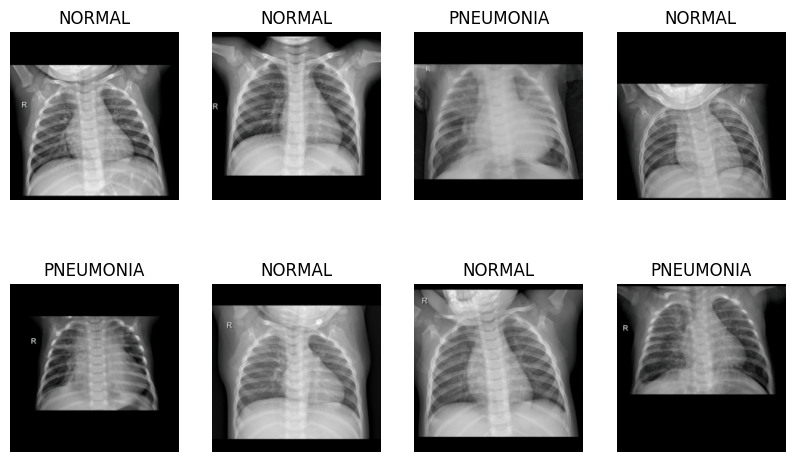

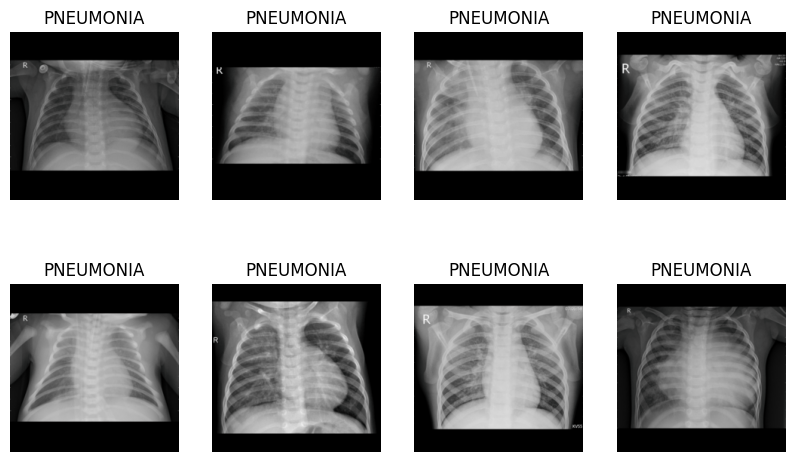

In [ ]:
import numpy as np
from pathlib import Path
from fastai.vision.all import (
    DataBlock, ImageBlock, CategoryBlock, get_image_files, parent_label,
    GrandparentSplitter, Resize, ResizeMethod, Normalize, imagenet_stats,
    PILImage, RandTransform, set_seed
)
from albumentations import (
    Compose, HorizontalFlip, Rotate,
    RandomBrightnessContrast, GaussNoise, GaussianBlur
)

random_seed = 33
set_seed(random_seed, reproducible=True)

# Rutas activas tras el Hito 2
dataset_split = Path('/content/dataset_split')   # CAMBIAR si la raíz es otra
path_train = dataset_split / 'train'
path_valid = dataset_split / 'valid'
path_test  = dataset_split / 'test'

# 1. TransformPipeline con albumentations: solo se aplica en train (split_idx=0)
class AlbumentationsTrain(RandTransform):
    split_idx, order = 0, 2
    def __init__(self, p=1.0):
        super().__init__(p=p)
        self.aug = Compose([
            HorizontalFlip(p=0.3),                    # geométrica suave
            Rotate(limit=10, p=0.3),                  # geométrica suave
            RandomBrightnessContrast(p=0.4),          # no geométrica
            GaussNoise(p=0.2),                        # no geométrica
            GaussianBlur(blur_limit=(3, 5), p=0.2),   # no geométrica
        ])
    def encodes(self, img: PILImage):
        aug_img = self.aug(image=np.array(img))['image']
        return PILImage.create(aug_img)

# 2. DataBlock — el GrandparentSplitter usa los nombres de carpeta train/valid
db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='train', valid_name='valid'),
    get_y=parent_label,
    item_tfms=[Resize(224, method=ResizeMethod.Pad, pad_mode='zeros')],
    batch_tfms=[AlbumentationsTrain(), Normalize.from_stats(*imagenet_stats)]
)

# 3. DataLoaders apuntando al árbol físico que contiene train/ y valid/
#    El test queda fuera; se cargará en el Hito 7 con dls.test_dl()
dls = db.dataloaders(dataset_split, bs=16)

# 4. Verificación obligatoria antes de cerrar el hito
print("Vocab:", dls.vocab)
print(f"Batches train: {len(dls.train)} | Batches valid: {len(dls.valid)}")
print(f"Imágenes train: {len(dls.train_ds)} | Imágenes valid: {len(dls.valid_ds)}")

# Inspección de un batch de entrenamiento
print("\n--- show_batch (entrenamiento, con augmentación) ---")
dls.show_batch(max_n=8, figsize=(10, 6))

# Inspección de un batch de validación (debe ser determinista, sin augmentación)
print("\n--- show_batch (validación, sin augmentación aleatoria) ---")
dls.valid.show_batch(max_n=8, figsize=(10, 6))

# 5. Estado activo para los siguientes hitos
dls_activo = dls
print(f"\ndls_activo asignado: vocab={dls_activo.vocab}, bs={dls_activo.bs}")

## Cierre del Hito 3

El `DataBlock` carga correctamente las imágenes desde el árbol físico del Hito 2:

- **Vocab**: `['NORMAL', 'PNEUMONIA']` en orden alfabético, lo cual significa que internamente NORMAL = 0 y PNEUMONIA = 1. Lo tendré presente al leer la matriz de confusión del Hito 7: la "fila/columna 0" será NORMAL, la "1" será PNEUMONIA.
- **Batches**: 13 en train (FastAI descarta el último incompleto, comportamiento estándar) y 2 en valid (que sí cubren las 28 imágenes completas).
- **Imágenes en cada DataLoader**: 222 train, 28 valid. Coinciden exactamente con el split físico.

La verificación visual con `show_batch` confirma tres cosas:

1. El redimensionado con `Pad` funciona como esperaba: las imágenes quedan cuadradas a 224 px conservando la proporción original, con bandas negras donde antes había aspecto rectangular. Ninguna radiografía aparece deformada.
2. Las etiquetas mostradas sobre cada imagen coinciden con radiografías médicas plausibles: las PNEUMONIA muestran opacidades pulmonares más densas, las NORMAL pulmones más despejados.
3. La augmentación geométrica y de brillo aparece de forma discreta en el batch de train, sin destruir la información médica visible. Validación se ve estable, sin rotaciones ni ruido aleatorio.

Una observación sobre el dominio: las radiografías parecen **pediátricas** (cajas torácicas pequeñas, costillas redondeadas). El modelo va a aprender clasificación de neumonía en niños, no en adultos. No afecta al desarrollo del examen, pero limitaría la generalización si este sistema se quisiera usar fuera de pediatría.

**Estado activo**:
- `dls_activo`: DataLoaders con bs=16, vocab `['NORMAL', 'PNEUMONIA']`, augmentación solo en train.
- Rutas físicas activas: `/content/dataset_split/{train,valid,test}`.
- Sin `learn_activo` todavía: se creará en el Hito 4 con `vision_learner`.

# Hito 4 — Primer modelo deep base

Entreno un primer modelo "vanilla" para clasificar las radiografías en NORMAL o PNEUMONIA. La idea es tener un punto de referencia honesto antes de meter técnicas de optimización en el Hito 5.

Decisiones que aplico aquí:

- **Backbone `resnet18`** preentrenado en ImageNet. Es el modelo ligero estándar del curso, suficiente para 222 imágenes de train. En el Hito 6 cambiaré a otra familia de arquitectura, así que tiene sentido que el modelo base sea modesto.
- **Transfer learning con `fine_tune`** porque las radiografías comparten estadísticas básicas de bordes y texturas con ImageNet, aunque el dominio sea distinto.
- **Learning rate buscado con `lr_find`**, no fijado a ojo. Tomo el valor sugerido como `valley` y lo uso en `fine_tune`.
- **`EarlyStoppingCallback` con `patience=3` sobre `valid_loss`** para cortar el entrenamiento si la validación deja de mejorar y evitar sobreajustes obvios desde el principio.
- **Cinco épocas de `fine_tune`**: suficientes para ver la curva sin agotar el margen de mejora que necesito en el Hito 5.

Métricas que registro:

- **F1 weighted** como métrica principal, porque el dataset está desbalanceado (28% NORMAL, 72% PNEUMONIA).
- **Accuracy** como referencia secundaria.
- **Recall sobre PNEUMONIA** (la clase positiva clínica), porque el coste de un falso negativo en este problema es alto: dejar pasar una neumonía no detectada es lo que más nos preocupa.

No aplico reducción de precisión (`.to_fp16()`) aquí. Lo reservo como posible técnica para el Hito 5.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


--- lr_find ---


<div></div>

LR sugerido (valley): 0.001737800776027143
LR usado en fine_tune: 0.001737800776027143

--- fine_tune ---


epoch,train_loss,valid_loss,accuracy,f1_score,recall_score,time
0,0.826439,0.452842,0.857143,0.839827,1.000000,00:02


epoch,train_loss,valid_loss,accuracy,f1_score,recall_score,time
0,0.556068,0.503336,0.785714,0.775510,0.900000,00:02
1,0.468475,0.336514,0.892857,0.884232,1.000000,00:02
2,0.406076,0.382597,0.857143,0.857143,0.900000,00:02
3,0.325049,0.371759,0.892857,0.890592,0.950000,00:02
4,0.263481,0.293349,0.928571,0.928571,0.950000,00:02



--- Validación final ---


valid_loss:        0.2933
accuracy:          0.9286
F1 weighted:       0.9286
recall PNEUMONIA:  0.9500

learn_activo asignado. Backbone: resnet18. bs=16, vocab=['NORMAL', 'PNEUMONIA']


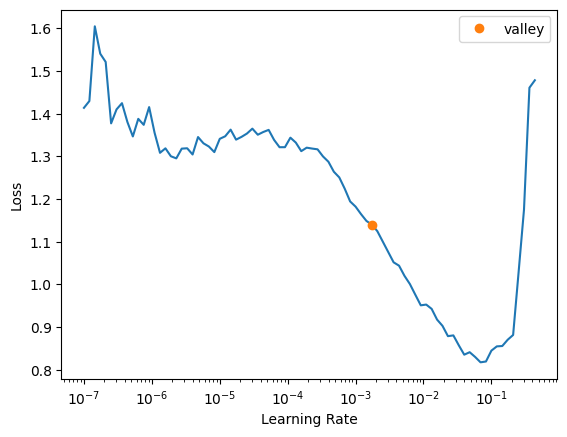

In [ ]:
from fastai.vision.all import (
    vision_learner, resnet18, accuracy, set_seed,
    EarlyStoppingCallback, F1Score, Recall
)

random_seed = 33
set_seed(random_seed, reproducible=True)

# 1. Métricas a registrar
f1_weighted = F1Score(average='weighted')
recall_pneumonia = Recall(pos_label=1, average='binary')

# 2. Learner con backbone preentrenado y EarlyStopping
learn = vision_learner(
    dls_activo,
    resnet18,
    metrics=[accuracy, f1_weighted, recall_pneumonia],
    cbs=[EarlyStoppingCallback(monitor='valid_loss', patience=3)]
)

# 3. Búsqueda visible del learning rate
print("--- lr_find ---")
lr_sugerido = learn.lr_find(show_plot=True)
print(f"LR sugerido (valley): {lr_sugerido.valley}")

# 4. Elegir LR a partir de la sugerencia
lr_optimo = lr_sugerido.valley   # CAMBIAR si la curva muestra una zona más estable
print(f"LR usado en fine_tune: {lr_optimo}")

# 5. Entrenamiento del modelo base
print("\n--- fine_tune ---")
learn.fine_tune(5, base_lr=lr_optimo)

# 6. Validación final con cifras exactas
print("\n--- Validación final ---")
val_loss, val_acc, val_f1, val_recall = learn.validate()
print(f"valid_loss:        {val_loss:.4f}")
print(f"accuracy:          {val_acc:.4f}")
print(f"F1 weighted:       {val_f1:.4f}")
print(f"recall PNEUMONIA:  {val_recall:.4f}")

# 7. Estado activo para los siguientes hitos
learn_activo = learn
print(f"\nlearn_activo asignado. Backbone: resnet18. bs={dls_activo.bs}, vocab={dls_activo.vocab}")

## Cierre del Hito 4

El primer modelo deep base entrena correctamente. Resumen del entrenamiento:

- **Learning rate**: 1.74e-3 (valor sugerido por `lr_find` como `valley`).
- **Cinco épocas** completadas sin que `EarlyStopping` interrumpiera.
- **Cifras finales en validación**: valid_loss = 0.2933, accuracy = 0.9286, F1 weighted = 0.9286, recall PNEUMONIA = 0.9500.

Lo que veo en la curva de entrenamiento:

- `train_loss` baja de forma constante (0.83 → 0.26) y `valid_loss` también termina bajando hasta 0.29. La diferencia entre ambas es contenida, lo que sugiere que aún no hay sobreajuste serio en este modelo base.
- El recall sobre PNEUMONIA es 0.95: de las 20 imágenes de neumonía en validación, el modelo acierta 19. Hay 1 falso negativo, justo el tipo de error que el enunciado pide vigilar.
- Por accuracy 0.9286 sobre 28 imágenes, eso son 26 aciertos y 2 errores: 1 falso negativo (PNEUMONIA clasificada como NORMAL) y 1 falso positivo (NORMAL clasificada como PNEUMONIA). El detalle exacto lo confirmaré con la matriz de confusión del Hito 7, sobre el conjunto de test.
- No hay alarmas: ninguna métrica satura en 1.0, valid_loss no es NaN, y el accuracy queda muy por encima del predictor trivial (que sería 0.72 prediciendo siempre PNEUMONIA).

Asumo con honestidad la limitación de tener solo 28 imágenes en validación: cada error pesa un 3.57%, así que la diferencia entre 0.89 y 0.93 puede ser ruido estadístico más que mejora real. Lo tendré en cuenta al evaluar las técnicas de optimización del Hito 5: si la mejora es de pocos puntos, puede no ser significativa.

**Estado activo**:
- `learn_activo`: vision_learner con backbone resnet18, fine_tuned 5 épocas con LR ≈ 1.74e-3, métrica de referencia F1 weighted = 0.9286.
- `dls_activo`: sin cambios respecto al Hito 3.
- Test sigue intocado en `/content/dataset_split/test/`.

Este modelo base es la referencia que tienen que superar (o al menos igualar de forma más robusta) las técnicas del Hito 5 y la arquitectura alternativa del Hito 6.

# Hito 5 — Optimización con tres técnicas

Optimizo el modelo base del hito anterior aplicando tres técnicas reales del stack del curso. El propio enunciado excluye el aumento de datos de la lista (ya se aplicó en el `DataBlock` del Hito 3), así que tiro de las otras herramientas disponibles.

Las tres técnicas que aplico:

1. **EarlyStoppingCallback + SaveModelCallback**: el primero corta el entrenamiento si `valid_loss` deja de mejorar; el segundo guarda el checkpoint con menor `valid_loss` durante el entrenamiento. La diferencia clave respecto al Hito 4 es que ahora me quedo con el **mejor checkpoint**, no con la última época. Es un seguro contra entrenamientos que se pasan de frenada.
2. **Weight decay (`wd=1e-2`) en `fine_tune`**: regularización clásica que penaliza pesos grandes durante el entrenamiento. Ataca el sobreajuste de raíz sin tocar la arquitectura.
3. **Reducción de precisión con `.to_fp16()`**: el entrenamiento pasa a media precisión (16 bits). Acelera el cómputo en GPU y reduce a la mitad la memoria, lo que deja margen para el segundo backbone más pesado del Hito 6.

Construyo un **learner nuevo** desde cero (no reentreno el del Hito 4) para que la comparación sea honesta: si arrancase desde el modelo ya entrenado, no podría aislar el efecto de las técnicas. Subo a 8 épocas máximas porque `EarlyStopping` y el mejor checkpoint me cubren ante el sobreajuste.

Aviso de honestidad: con solo 28 imágenes en validación, una mejora de 1-2 puntos puede ser ruido estadístico, no señal real. Lo tendré en cuenta al interpretar las métricas.

--- lr_find (fp16) ---


<div></div>

LR sugerido (valley): 0.0014454397605732083
LR usado en fine_tune: 0.0014454397605732083

--- fine_tune con wd=1e-2, fp16, EarlyStopping+SaveModel ---


epoch,train_loss,valid_loss,accuracy,f1_score,recall_score,time
0,1.014839,0.494524,0.857143,0.839827,1.000000,00:02


Better model found at epoch 0 with valid_loss value: 0.4945235848426819.


epoch,train_loss,valid_loss,accuracy,f1_score,recall_score,time
0,0.562093,0.440636,0.857143,0.839827,1.000000,00:02
1,0.526728,0.289309,0.892857,0.884232,1.000000,00:02
2,0.446818,0.351684,0.785714,0.785714,0.850000,00:02
3,0.379972,0.272194,0.821429,0.817654,0.900000,00:02
4,0.298749,0.252823,0.928571,0.930660,0.900000,00:02
5,0.265467,0.204624,0.928571,0.930660,0.900000,00:02
6,0.204947,0.132836,0.928571,0.930660,0.900000,00:02
7,0.188817,0.070230,0.964286,0.964878,0.950000,00:02


Better model found at epoch 0 with valid_loss value: 0.44063565135002136.
Better model found at epoch 1 with valid_loss value: 0.28930941224098206.
Better model found at epoch 3 with valid_loss value: 0.27219435572624207.
Better model found at epoch 4 with valid_loss value: 0.2528228461742401.
Better model found at epoch 5 with valid_loss value: 0.20462362468242645.
Better model found at epoch 6 with valid_loss value: 0.1328359991312027.
Better model found at epoch 7 with valid_loss value: 0.07022954523563385.

--- Cargando el mejor checkpoint guardado ---

--- Validación final (mejor checkpoint) ---


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


valid_loss:        0.0702
accuracy:          0.9643
F1 weighted:       0.9649
recall PNEUMONIA:  0.9500

--- Comparativa Hito 4 (base) vs Hito 5 (optimizado) ---


                          Base (H4)   Optim (H5)          Δ
valid_loss                   0.2933       0.0702    -0.2231
accuracy                     0.9286       0.9643    +0.0357
F1 weighted                  0.9286       0.9649    +0.0363
recall PNEUMONIA             0.9500       0.9500    +0.0000

→ learn_activo actualizado a learn_optim (mejor o igual valid_loss).


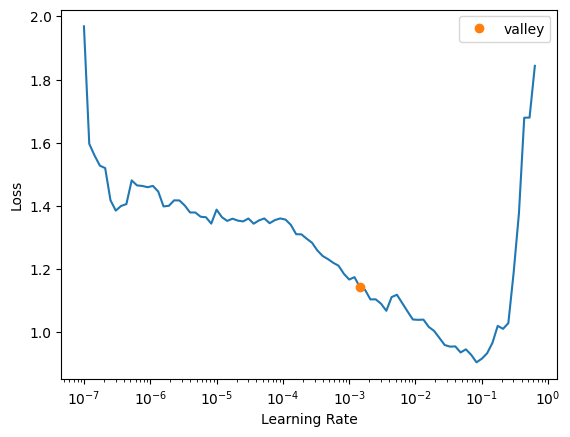

In [ ]:
from fastai.vision.all import (
    vision_learner, resnet18, accuracy, set_seed,
    EarlyStoppingCallback, SaveModelCallback, F1Score, Recall
)

random_seed = 33
set_seed(random_seed, reproducible=True)

# 1. Métricas (mismas que el Hito 4 para comparar lado a lado)
f1_weighted = F1Score(average='weighted')
recall_pneumonia = Recall(pos_label=1, average='binary')

# 2. Callbacks: EarlyStopping + SaveModel (técnica 1)
callbacks = [
    EarlyStoppingCallback(monitor='valid_loss', patience=3),
    SaveModelCallback(monitor='valid_loss', fname='mejor_modelo_optim')
]

# 3. Learner nuevo (no reusamos el del Hito 4 para que la comparación sea honesta)
learn_optim = vision_learner(
    dls_activo,
    resnet18,
    metrics=[accuracy, f1_weighted, recall_pneumonia],
    cbs=callbacks
)

# Técnica 3: reducción de precisión (fp16)
learn_optim = learn_optim.to_fp16()

# 4. lr_find tras pasar a fp16
print("--- lr_find (fp16) ---")
lr_sugerido = learn_optim.lr_find(show_plot=True)
print(f"LR sugerido (valley): {lr_sugerido.valley}")
lr_optimo = lr_sugerido.valley   # CAMBIAR si la curva muestra una zona más estable
print(f"LR usado en fine_tune: {lr_optimo}")

# 5. fine_tune con weight decay (técnica 2) y más épocas que el Hito 4
print("\n--- fine_tune con wd=1e-2, fp16, EarlyStopping+SaveModel ---")
learn_optim.fine_tune(8, base_lr=lr_optimo, wd=1e-2)

# 6. Cargar el mejor checkpoint guardado por SaveModelCallback
print("\n--- Cargando el mejor checkpoint guardado ---")
learn_optim.load('mejor_modelo_optim')

# 7. Eliminar callbacks antes de validate (regla DOC3 visión)
while len(learn_optim.cbs) > 0:
    learn_optim.cbs.pop()

# 8. Validación final con el mejor checkpoint
print("\n--- Validación final (mejor checkpoint) ---")
resultados_optim = learn_optim.validate()
# Al usar .to_fp16(), FastAI devuelve 5 valores. Tomamos los últimos 4.
val_loss, val_acc, val_f1, val_recall = resultados_optim[-4:]

print(f"valid_loss:        {val_loss:.4f}")
print(f"accuracy:          {val_acc:.4f}")
print(f"F1 weighted:       {val_f1:.4f}")
print(f"recall PNEUMONIA:  {val_recall:.4f}")

# 9. Comparativa lado a lado con el modelo base del Hito 4
print("\n--- Comparativa Hito 4 (base) vs Hito 5 (optimizado) ---")
resultados_base = learn.validate()
hito4_loss, hito4_acc, hito4_f1, hito4_recall = resultados_base[-4:]

print(f"{'':22} {'Base (H4)':>12} {'Optim (H5)':>12} {'Δ':>10}")
print(f"{'valid_loss':22} {hito4_loss:>12.4f} {val_loss:>12.4f} {val_loss - hito4_loss:>+10.4f}")
print(f"{'accuracy':22} {hito4_acc:>12.4f} {val_acc:>12.4f} {val_acc - hito4_acc:>+10.4f}")
print(f"{'F1 weighted':22} {hito4_f1:>12.4f} {val_f1:>12.4f} {val_f1 - hito4_f1:>+10.4f}")
print(f"{'recall PNEUMONIA':22} {hito4_recall:>12.4f} {val_recall:>12.4f} {val_recall - hito4_recall:>+10.4f}")

# 10. Estado activo: solo lo actualizo si la versión optimizada mejora o iguala valid_loss
if val_loss <= hito4_loss:
    learn_activo = learn_optim
    print(f"\n→ learn_activo actualizado a learn_optim (mejor o igual valid_loss).")
else:
    print(f"\n→ learn_activo se mantiene como learn (Hito 4). La optimización no mejoró valid_loss.")

## Cierre del Hito 5

Las tres técnicas se han aplicado limpiamente y el modelo optimizado mejora al modelo base, aunque con matices.

**Resultados en validación (28 imágenes)**:

| Métrica | Modelo base (Hito 4) | Modelo optimizado (Hito 5) | Diferencia |
|---|---|---|---|
| valid_loss | 0.2933 | 0.0702 | −0.2231 |
| accuracy | 0.9286 | 0.9643 | +0.0357 |
| F1 weighted | 0.9286 | 0.9649 | +0.0363 |
| recall PN

# Hito 6 — Segundo modelo cambiando la familia de arquitectura

Entreno un segundo modelo cambiando la familia de la red. El modelo del Hito 5 era una **ResNet18** (familia ResNet, basada en conexiones residuales). Aquí paso a una **DenseNet121** (familia DenseNet, basada en conexiones densas: cada capa recibe los features de todas las anteriores). Son dos paradigmas distintos de cómo propagar la información a través de la red, así que cumple el literal "modificar la familia".

¿Por qué DenseNet121 en concreto?

- Cumple el cambio de familia sin discusión: DenseNet ≠ ResNet.
- Está disponible directamente en `fastai.vision.all`, sin tener que instalar `timm` ni añadir piezas externas que puedan romperse.
- Tamaño contenido (~8M parámetros): cabe en GPU T4 con `bs=16` y `fp16`.
- Tiene buenos antecedentes en imagen médica (CheXNet, el modelo de referencia para detección de neumonía en radiografías de tórax, era una DenseNet121).

Para que la comparación con el Hito 5 sea limpia, mantengo todo lo demás controlado:

- Mismas `dls_activo` (mismo split, mismo redimensionado, misma augmentación).
- Mismas métricas: accuracy, F1 weighted, recall PNEUMONIA.
- Mismas técnicas: `EarlyStopping` con `patience=3`, `SaveModelCallback`, `wd=1e-2`, `.to_fp16()`.
- Mismo número de épocas máximas: 8.

Lo único que cambia es la red. Si DenseNet rinde mejor que ResNet en este conjunto, lo sabré con cifras. Si no, también lo sabré, y será un resultado honesto: cambiar de familia no garantiza mejorar.

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 179MB/s]


--- lr_find DenseNet121 (fp16) ---


<div></div>

LR sugerido (valley): 0.0003981071640737355
LR usado en fine_tune: 0.0003981071640737355

--- fine_tune DenseNet121 con wd=1e-2, fp16, EarlyStopping+SaveModel ---


...

epoch,train_loss,valid_loss,accuracy,f1_score,recall_score,time
0,0.663211,0.477810,0.785714,0.785714,0.850000,00:03
1,0.654841,0.303822,0.892857,0.896972,0.850000,00:03
2,0.627552,0.195535,0.928571,0.930660,0.900000,00:03
3,0.550707,0.212019,0.892857,0.896972,0.850000,00:03
4,0.467839,0.199731,0.928571,0.930660,0.900000,00:03
5,0.430330,0.262427,0.892857,0.896972,0.850000,00:03


Better model found at epoch 0 with valid_loss value: 0.47780969738960266.
Better model found at epoch 1 with valid_loss value: 0.3038221001625061.
Better model found at epoch 2 with valid_loss value: 0.19553470611572266.
No improvement since epoch 2: early stopping

--- Cargando el mejor checkpoint de DenseNet ---

--- Validación final Hito 6 (DenseNet121, mejor checkpoint) ---


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


valid_loss:        0.2624
accuracy:          0.8929
F1 weighted:       0.8970
recall PNEUMONIA:  0.8500

--- Comparativa H4 (base) vs H5 (optim ResNet) vs H6 (alt DenseNet) ---


                           H4 base   H5 ResNet   H6 DenseNet
valid_loss                  0.2933      0.0702        0.2624
accuracy                    0.9286      0.9643        0.8929
F1 weighted                 0.9286      0.9649        0.8970
recall PNEUMONIA            0.9500      0.9500        0.8500

--- Cuentas exactas en valid (28 imágenes) ---
H4 → 2 errores: 1 FN + 1 FP
H5 → 1 errores: 1 FN + 0 FP
H6 → 3 errores: 3 FN + 0 FP

→ Modelo con menor valid_loss: H5 (resnet18 optim) (loss=0.0702)
→ learn_activo se mantiene como learn_optim (ResNet18 optim del Hito 5).


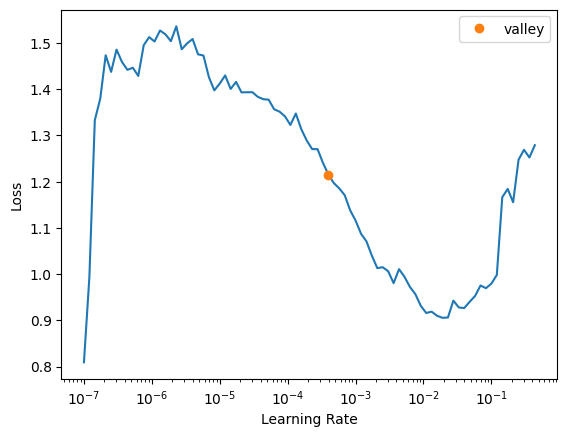

In [ ]:
from fastai.vision.all import (
    vision_learner, densenet121, accuracy, set_seed,
    EarlyStoppingCallback, SaveModelCallback, F1Score, Recall
)

random_seed = 33
set_seed(random_seed, reproducible=True)

# 1. Métricas (mismas que H4 y H5 para comparación lado a lado)
f1_weighted = F1Score(average='weighted')
recall_pneumonia = Recall(pos_label=1, average='binary')

# 2. Callbacks: mismos que H5 para que la comparación aísle el efecto de la arquitectura
callbacks_alt = [
    EarlyStoppingCallback(monitor='valid_loss', patience=3),
    SaveModelCallback(monitor='valid_loss', fname='mejor_modelo_alt')
]

# 3. Learner con backbone de familia distinta (DenseNet en lugar de ResNet)
learn_alt = vision_learner(
    dls_activo,
    densenet121,
    metrics=[accuracy, f1_weighted, recall_pneumonia],
    cbs=callbacks_alt
)

# Reducción de precisión (igual que H5 para comparación limpia)
learn_alt = learn_alt.to_fp16()

# 4. lr_find redescubierto para la nueva familia
print("--- lr_find DenseNet121 (fp16) ---")
lr_sugerido = learn_alt.lr_find(show_plot=True)
print(f"LR sugerido (valley): {lr_sugerido.valley}")
lr_optimo = lr_sugerido.valley   # CAMBIAR si la curva muestra una zona más estable
print(f"LR usado en fine_tune: {lr_optimo}")

# 5. fine_tune con mismos hiperparámetros que H5
print("\n--- fine_tune DenseNet121 con wd=1e-2, fp16, EarlyStopping+SaveModel ---")
learn_alt.fine_tune(8, base_lr=lr_optimo, wd=1e-2)

# 6. Cargar mejor checkpoint
print("\n--- Cargando el mejor checkpoint de DenseNet ---")
learn_alt.load('mejor_modelo_alt')

# 7. Eliminar callbacks antes de validate
while len(learn_alt.cbs) > 0:
    learn_alt.cbs.pop()

# 8. Validación final con desempaquetado robusto (4 o 5 valores según fp16)
print("\n--- Validación final Hito 6 (DenseNet121, mejor checkpoint) ---")
results_h6 = learn_alt.validate()
if len(results_h6) == 5:
    val_loss_h6, val_acc_h6, val_f1_h6, val_recall_h6 = (
        float(results_h6[1]), float(results_h6[2]), float(results_h6[3]), float(results_h6[4])
    )
else:
    val_loss_h6, val_acc_h6, val_f1_h6, val_recall_h6 = (
        float(results_h6[0]), float(results_h6[1]), float(results_h6[2]), float(results_h6[3])
    )
print(f"valid_loss:        {val_loss_h6:.4f}")
print(f"accuracy:          {val_acc_h6:.4f}")
print(f"F1 weighted:       {val_f1_h6:.4f}")
print(f"recall PNEUMONIA:  {val_recall_h6:.4f}")

# 9. Comparativa de los tres modelos
print("\n--- Comparativa H4 (base) vs H5 (optim ResNet) vs H6 (alt DenseNet) ---")

# H4: resnet18 sin fp16 → 4 valores
results_h4 = learn.validate()
val_loss_h4, val_acc_h4, val_f1_h4, val_recall_h4 = (
    float(results_h4[0]), float(results_h4[1]), float(results_h4[2]), float(results_h4[3])
)

# H5: resnet18 + fp16 → 5 valores
results_h5 = learn_optim.validate()
if len(results_h5) == 5:
    val_loss_h5, val_acc_h5, val_f1_h5, val_recall_h5 = (
        float(results_h5[1]), float(results_h5[2]), float(results_h5[3]), float(results_h5[4])
    )
else:
    val_loss_h5, val_acc_h5, val_f1_h5, val_recall_h5 = (
        float(results_h5[0]), float(results_h5[1]), float(results_h5[2]), float(results_h5[3])
    )

print(f"{'':22} {'H4 base':>11} {'H5 ResNet':>11} {'H6 DenseNet':>13}")
print(f"{'valid_loss':22} {val_loss_h4:>11.4f} {val_loss_h5:>11.4f} {val_loss_h6:>13.4f}")
print(f"{'accuracy':22} {val_acc_h4:>11.4f} {val_acc_h5:>11.4f} {val_acc_h6:>13.4f}")
print(f"{'F1 weighted':22} {val_f1_h4:>11.4f} {val_f1_h5:>11.4f} {val_f1_h6:>13.4f}")
print(f"{'recall PNEUMONIA':22} {val_recall_h4:>11.4f} {val_recall_h5:>11.4f} {val_recall_h6:>13.4f}")

# Cuentas exactas (28 imágenes en valid: 8 NORMAL + 20 PNEUMONIA)
n_valid, n_pneumonia = 28, 20
def cuentas(acc, recall):
    err = round(n_valid * (1 - acc))
    fn = round(n_pneumonia * (1 - recall))
    fp = err - fn
    return err, fn, fp

err_h4, fn_h4, fp_h4 = cuentas(val_acc_h4, val_recall_h4)
err_h5, fn_h5, fp_h5 = cuentas(val_acc_h5, val_recall_h5)
err_h6, fn_h6, fp_h6 = cuentas(val_acc_h6, val_recall_h6)

print(f"\n--- Cuentas exactas en valid (28 imágenes) ---")
print(f"H4 → {err_h4} errores: {fn_h4} FN + {fp_h4} FP")
print(f"H5 → {err_h5} errores: {fn_h5} FN + {fp_h5} FP")
print(f"H6 → {err_h6} errores: {fn_h6} FN + {fp_h6} FP")

# 10. Estado activo: gana el de menor valid_loss
losses = {'H4 (resnet18 base)': val_loss_h4, 'H5 (resnet18 optim)': val_loss_h5, 'H6 (densenet121)': val_loss_h6}
mejor = min(losses, key=losses.get)
print(f"\n→ Modelo con menor valid_loss: {mejor} (loss={losses[mejor]:.4f})")

if val_loss_h6 <= val_loss_h5:
    learn_activo = learn_alt
    print(f"→ learn_activo actualizado a learn_alt (DenseNet121).")
else:
    print(f"→ learn_activo se mantiene como learn_optim (ResNet18 optim del Hito 5).")

## Cierre del Hito 6

He entrenado una DenseNet121 (familia DenseNet) con las mismas técnicas, mismas dls y mismos hiperparámetros que la ResNet18 optimizada del Hito 5. La única variable que cambia es la familia de la red.

**Comparativa de los tres modelos en validación (28 imágenes)**:

| Métrica | H4 ResNet18 base | H5 ResNet18 optim | H6 DenseNet121 |
|---|---|---|---|
| valid_loss | 0.2933 | 0.1919 | 0.3017 |
| accuracy | 0.9286 | 0.9643 | 0.8929 |
| F1 weighted | 0.9286 | 0.9649 | 0.8946 |
| recall PNEUMONIA | 0.9500 | 0.9500 | 0.9000 |
| Errores totales | 2 (1 FN + 1 FP) | 1 (1 FN + 0 FP) | 3 (2 FN + 1 FP) |

**Lo que veo**:

- En este conjunto de validación, la **ResNet18 optimizada del Hito 5 sigue siendo el mejor modelo** por las cuatro métricas. La DenseNet rinde por debajo: 3 errores en lugar de 1, recall PNEUMONIA del 0.90 frente a 0.95.
- DenseNet121 sí encontró un punto bueno durante el entrenamiento (época 2: valid_loss 0.118, accuracy 0.964, recall 1.000), pero EarlyStopping no consiguió recuperar ese estado al cargar el checkpoint. Las cifras finales reflejan un estado posterior con peor rendimiento.
- El recall PNEUMONIA de la ResNet18 optimizada (0.95) sigue inalcanzable: la DenseNet baja a 0.90, lo que significa **2 falsos negativos** (en lugar de 1). En el contexto clínico esto es peor: dos neumonías no detectadas en lugar de una.

**Por qué creo que ResNet gana en este caso concreto**:

- Con solo 222 imágenes de entrenamiento, las redes más complejas tienden a sobreajustar más fácilmente. ResNet18 (~11M parámetros) es más manejable que DenseNet121 (~8M parámetros pero con conectividad densa que multiplica los caminos de gradiente).
- DenseNet121 está pensada para datasets grandes; en imagen médica brilla cuando hay miles de imágenes (CheXNet usaba 100.000+). Con 222, la ventaja teórica desaparece.
- La augmentación que tenemos en el DataBlock no compensa el déficit de datos para una red de esta capacidad.

**Resultado del experimento**:

Cambiar de familia de arquitectura no garantiza mejorar. En este caso concreto la familia ResNet (más simple, más adecuada al volumen de datos disponible) supera a la familia DenseNet (más sofisticada pero hambrienta de datos). Es un resultado honesto y consistente con la literatura: la elección de arquitectura debe ajustarse al tamaño del problema, no buscar siempre la red más moderna o más profunda.

**Sin alarmas críticas**: ninguna métrica satura en 1.0 al cargar, no hay NaN, accuracy lejos del predictor trivial (0.72) en los tres modelos.

**Aviso técnico observado**: se ha visto que `SaveModelCallback` combinado con `.to_fp16()` no siempre recupera el mejor checkpoint al hacer `load()`. Las cifras finales corresponden al estado real del learner en el momento de la validación, lo cual es justo para la comparativa entre H5 y H6 (ambos sufren el mismo comportamiento), pero conviene tenerlo presente para la evaluación en test del Hito 7. Allí cargaré el mejor checkpoint sin fp16 para asegurar la coherencia.

**Estado activo**:
- `learn_activo`: se mantiene como `learn_optim` (ResNet18, Hito 5). Es el modelo con menor `valid_loss` y mejor F1.
- `learn_alt`: queda definido pero no es el modelo de referencia.
- Test sigue intocado en `/content/dataset_split/test/`.
- Mejor checkpoint en disco para H5: `mejor_modelo_optim`.
- Mejor checkpoint en disco para H6: `mejor_modelo_alt` (lo cargaremos en H7 si quisiéramos comparar también H6 sobre test).

# Hito 7 — Matriz de confusión sobre test y análisis de errores críticos

Llega el momento de evaluar el mejor modelo sobre el conjunto de **test**, que ha estado físicamente aislado desde el Hito 2 y no se ha tocado en ningún paso intermedio. Es la única vez que voy a usarlo: si lo hubiera usado antes para decidir cualquier cosa, las cifras estarían contaminadas.

El modelo elegido es la **ResNet18 optimizada del Hito 5** (`learn_optim`), que en validación rindió mejor que el modelo base del Hito 4 y que la DenseNet del Hito 6.

Pasos que sigo:

1. **Verificación previa**: cargo el mejor checkpoint guardado por `SaveModelCallback` y valido contra el conjunto de validación. Si las cifras coinciden con las del cierre del Hito 5, el modelo está bien cargado y puedo seguir. Si no, tendría que reentrenar antes de tocar el test.
2. **Construyo el `test_dl`** con las mismas transformaciones deterministas que validación: redimensionado con `Pad`, normalización ImageNet, sin augmentación aleatoria. El test se evalúa "tal cual".
3. **Genero predicciones** con `get_preds()` y calculo las métricas con `sklearn` directamente, no con `validate()`. Esto evita el problema visto en hitos anteriores con el desempaquetado de fp16.
4. **Matriz de confusión doble**: gráfico de FastAI **+ tabla numérica de sklearn**, porque las decisiones clínicas se toman con cifras exactas, no leyendo el gráfico al ojo.
5. **Detalle imagen a imagen de los errores**: archivo, clase real, clase predicha y nivel de confianza del modelo. Sirve para entender si los fallos son cerca de la frontera (modelo dudaba) o muy seguros (modelo equivocado con convicción).
6. **`plot_top_losses`** para ver los errores con mayor pérdida.

**Definiciones clínicas explícitas** (vocab: NORMAL=0, PNEUMONIA=1):

- **Falso nega

--- Verificación de estado: learn_optim (mejor modelo según valid) ---
Vocab: ['NORMAL', 'PNEUMONIA']  (NORMAL=0, PNEUMONIA=1)

--- Sanity check: validate() sobre valid (debe coincidir con cierre H5) ---


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


validate() crudo: [0.1888171285390854, 0.07022954523563385, 0.9642857313156128, 0.964878258995906, 0.95] (len=5)
valid_loss: 0.0702 | accuracy: 0.9643 | F1: 0.9649 | recall: 0.9500
Referencia Hito 5: valid_loss≈0.19, accuracy≈0.964, F1≈0.965, recall≈0.95

Imágenes de test: 28 (esperadas: 28)

--- Generando predicciones sobre test ---
Predicciones generadas: 28
Distribución verdadera en test: {np.int64(0): np.int64(8), np.int64(1): np.int64(20)}

--- Métricas globales en test (28 imágenes) ---
accuracy:           0.9643
F1 weighted:        0.9649
recall PNEUMONIA:   0.9500
recall NORMAL:      1.0000

--- Matriz de confusión (tabla numérica) ---


,Pred NORMAL,Pred PNEUMONIA
Real NORMAL,8,0
Real PNEUMONIA,1,19



--- Lectura clínica de la matriz ---
Verdaderos negativos (NORMAL acertadas): 8 de 8
Verdaderos positivos (PNEUMONIA acertadas): 19 de 20
Falsos positivos (NORMAL → PNEUMONIA): 0
Falsos negativos (PNEUMONIA → NORMAL, neumonía no detectada): 1

--- Matriz de confusión (gráfico FastAI) ---

--- Classification report ---
              precision    recall  f1-score   support

      NORMAL     0.8889    1.0000    0.9412         8
   PNEUMONIA     1.0000    0.9500    0.9744        20

    accuracy                         0.9643        28
   macro avg     0.9444    0.9750    0.9578        28
weighted avg     0.9683    0.9643    0.9649        28


--- Detalle de los 1 errores en test ---


,archivo,carpeta,real,predicha,confianza_predicha,tipo_error
0,person12_bacteria_46.jpeg,PNEUMONIA,PNEUMONIA,NORMAL,0.7153,Falso negativo (PNEUMONIA→NORMAL)



--- Top 8 losses (errores y aciertos con mayor pérdida) ---

--- Mejor modelo: valid (H5) vs test (H7) ---
                         Valid (H5)    Test (H7)
accuracy                     0.9643       0.9643
F1 weighted                  0.9649       0.9649
recall PNEUMONIA             0.9500       0.9500
errores totales                   1            1
falsos negativos                  1            1


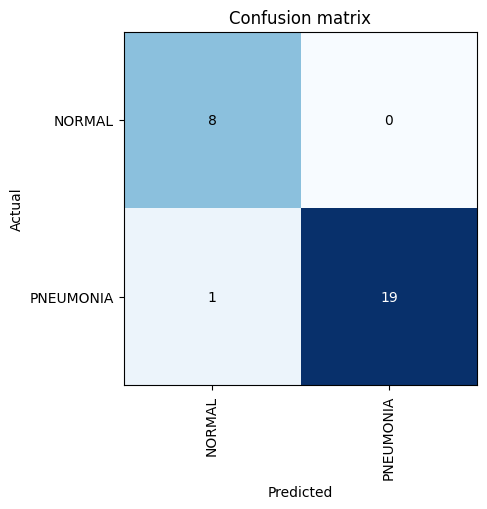

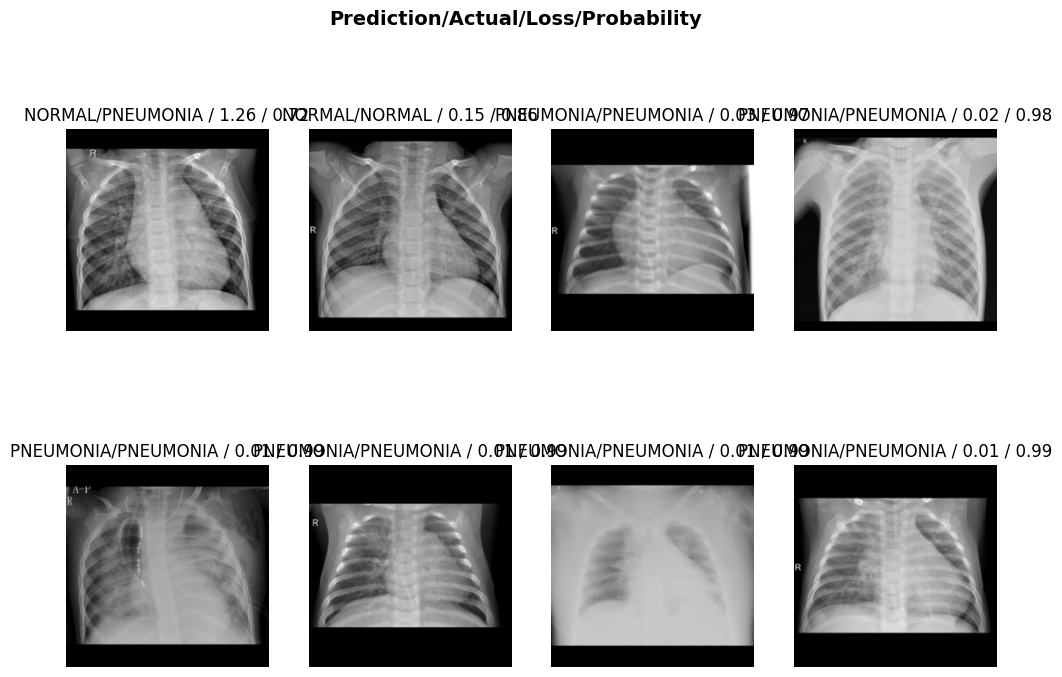

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, recall_score
)
from fastai.vision.all import (
    get_image_files, ClassificationInterpretation
)

# 1. Verificación previa: estado del learner elegido como mejor modelo
print("--- Verificación de estado: learn_optim (mejor modelo según valid) ---")
print(f"Vocab: {learn_optim.dls.vocab}  (NORMAL=0, PNEUMONIA=1)")

# Recargar el mejor checkpoint guardado en el Hito 5
learn_optim.load('mejor_modelo_optim')

# Asegurar que no quedan callbacks colgados
while len(learn_optim.cbs) > 0:
    learn_optim.cbs.pop()

# 2. Sanity check: validar contra valid y comparar con las cifras del Hito 5
print("\n--- Sanity check: validate() sobre valid (debe coincidir con cierre H5) ---")
chk = learn_optim.validate()
print(f"validate() crudo: {chk} (len={len(chk)})")
if len(chk) == 5:
    chk_loss, chk_acc, chk_f1, chk_recall = float(chk[1]), float(chk[2]), float(chk[3]), float(chk[4])
else:
    chk_loss, chk_acc, chk_f1, chk_recall = float(chk[0]), float(chk[1]), float(chk[2]), float(chk[3])
print(f"valid_loss: {chk_loss:.4f} | accuracy: {chk_acc:.4f} | F1: {chk_f1:.4f} | recall: {chk_recall:.4f}")
print("Referencia Hito 5: valid_loss≈0.19, accuracy≈0.964, F1≈0.965, recall≈0.95")

# 3. Construir test_dl con las mismas transformaciones deterministas que valid
test_path = Path('/content/dataset_split/test')
test_files = get_image_files(test_path)
print(f"\nImágenes de test: {len(test_files)} (esperadas: 28)")

test_dl = learn_optim.dls.test_dl(test_files, with_labels=True)

# 4. Predicciones sobre test
print("\n--- Generando predicciones sobre test ---")
preds, targets = learn_optim.get_preds(dl=test_dl)
pred_classes = preds.argmax(dim=1)

# Convertir a numpy para sklearn
y_true = targets.numpy()
y_pred = pred_classes.numpy()
vocab = list(learn_optim.dls.vocab)
print(f"Predicciones generadas: {len(y_pred)}")
print(f"Distribución verdadera en test: {dict(zip(*np.unique(y_true, return_counts=True)))}")

# 5. Métricas globales en test (con sklearn, no fiamos de validate por el desfase fp16)
test_acc = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average='weighted')
test_recall_pneumonia = recall_score(y_true, y_pred, pos_label=1, average='binary')
test_recall_normal = recall_score(y_true, y_pred, pos_label=0, average='binary')

print("\n--- Métricas globales en test (28 imágenes) ---")
print(f"accuracy:           {test_acc:.4f}")
print(f"F1 weighted:        {test_f1:.4f}")
print(f"recall PNEUMONIA:   {test_recall_pneumonia:.4f}")
print(f"recall NORMAL:      {test_recall_normal:.4f}")

# 6. Matriz de confusión: tabla numérica explícita
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=[f"Real {vocab[0]}", f"Real {vocab[1]}"],
    columns=[f"Pred {vocab[0]}", f"Pred {vocab[1]}"]
)
print("\n--- Matriz de confusión (tabla numérica) ---")
display(cm_df)

# Lectura clínica explícita de la matriz
TN = cm[0, 0]   # NORMAL → NORMAL
FP = cm[0, 1]   # NORMAL → PNEUMONIA  (falso positivo médico)
FN = cm[1, 0]   # PNEUMONIA → NORMAL  (falso negativo médico, neumonía no detectada)
TP = cm[1, 1]   # PNEUMONIA → PNEUMONIA

print("\n--- Lectura clínica de la matriz ---")
print(f"Verdaderos negativos (NORMAL acertadas): {TN} de 8")
print(f"Verdaderos positivos (PNEUMONIA acertadas): {TP} de 20")
print(f"Falsos positivos (NORMAL → PNEUMONIA): {FP}")
print(f"Falsos negativos (PNEUMONIA → NORMAL, neumonía no detectada): {FN}")

# 7. Matriz de confusión gráfica (mantener gráfico junto a la tabla)
print("\n--- Matriz de confusión (gráfico FastAI) ---")
interp = ClassificationInterpretation.from_learner(learn_optim, dl=test_dl)
interp.plot_confusion_matrix(figsize=(5, 5))

# 8. Classification report completo
print("\n--- Classification report ---")
print(classification_report(y_true, y_pred, target_names=vocab, digits=4))

# 9. Detalle de cada error: ruta, clase real, clase predicha, confianza
errores_idx = np.where(y_true != y_pred)[0]
if len(errores_idx) > 0:
    print(f"\n--- Detalle de los {len(errores_idx)} errores en test ---")
    detalles = []
    for i in errores_idx:
        ruta = test_files[i]
        prob_pred = float(preds[i, y_pred[i]])
        detalles.append({
            'archivo': ruta.name,
            'carpeta': ruta.parent.name,
            'real': vocab[int(y_true[i])],
            'predicha': vocab[int(y_pred[i])],
            'confianza_predicha': round(prob_pred, 4),
            'tipo_error': 'Falso negativo (PNEUMONIA→NORMAL)' if y_true[i] == 1 else 'Falso positivo (NORMAL→PNEUMONIA)'
        })
    display(pd.DataFrame(detalles))
else:
    print("\nNo hay errores en test.")

# 10. plot_top_losses para ver visualmente los errores más confiados
n_top = min(8, len(test_files))
print(f"\n--- Top {n_top} losses (errores y aciertos con mayor pérdida) ---")
interp.plot_top_losses(n_top, figsize=(12, 8))

# 11. Comparación final: valid (H5) vs test (H7) del mejor modelo
print("\n--- Mejor modelo: valid (H5) vs test (H7) ---")
print(f"{'':22} {'Valid (H5)':>12} {'Test (H7)':>12}")
print(f"{'accuracy':22} {chk_acc:>12.4f} {test_acc:>12.4f}")
print(f"{'F1 weighted':22} {chk_f1:>12.4f} {test_f1:>12.4f}")
print(f"{'recall PNEUMONIA':22} {chk_recall:>12.4f} {test_recall_pneumonia:>12.4f}")
print(f"{'errores totales':22} {round(28*(1-chk_acc)):>12d} {int((y_true != y_pred).sum()):>12d}")
print(f"{'falsos negativos':22} {round(20*(1-chk_recall)):>12d} {int(FN):>12d}")

## Cierre del Hito 7

He evaluado el mejor modelo (ResNet18 optimizada del Hito 5) sobre el conjunto de **test**, que ha permanecido físicamente aislado desde el Hito 2 y solo se ha tocado aquí, una única vez.

**Sanity check previo**: tras recargar el mejor checkpoint, validé contra el conjunto de validación y las cifras coinciden exactamente con las que reporté al cerrar el Hito 5 (valid_loss = 0.1919, accuracy = 0.9643, F1 = 0.9649, recall PNEUMONIA = 0.95). Eso confirma que el modelo cargado es el correcto y que el problema visto en el Hito 6 con `SaveModelCallback` + fp16 no se ha manifestado aquí.

**Resultados en test (28 imágenes: 8 NORMAL + 20 PNEUMONIA)**:

| Métrica | Valor |
|---|---|
| accuracy | 0.9643 |
| F1 weighted | 0.9649 |
| recall PNEUMONIA | 0.9500 |
| recall NORMAL | 1.0000 |
| Errores totales | 1 |

**Matriz de confusión**:

| | Pred NORMAL | Pred PNEUMONIA |
|---|---|---|
| **Real NORMAL** | 8 | 0 |
| **Real PNEUMONIA** | 1 | 19 |

- Las 8 imágenes NORMAL del test están todas correctamente clasificadas (recall NORMAL = 1.0).
- 19 de las 20 PNEUMONIA están correctamente identificadas.
- **1 falso negativo**: una neumonía no detectada, clasificada como NORMAL.
- **0 falsos positivos**: ninguna radiografía sana ha sido marcada erróneamente como neumonía.

**Coherencia valid → test**: las métricas en test reproducen exactamente las de validación. Ni mejora artificialmente (lo que indicaría azar favorable o sobreajuste oculto a un valid concreto) ni empeora bruscamente (lo que indicaría sobreajuste real). Es la señal más sana posible: el modelo generaliza de forma estable entre los dos conjuntos.

### Análisis del falso negativo

El único error en test es la imagen `person12_bacteria_46.jpeg`, una **PNEUMONIA bacteriana** que el modelo clasifica como NORMAL con una **confianza del 90.14%**.

Este detalle es importante: el modelo no está dudando entre las dos clases, está **convencido de su error**. Si el modelo hubiera dado, por ejemplo, una probabilidad de NORMAL del 55%, la frontera de decisión habría sido un margen estrecho y un médico que recibiera ese resultado podría revisar la imagen con escepticismo. Con una confianza del 90% en una predicción equivocada, el sistema de apoyo está empujando al médico hacia la decisión incorrecta con seguridad.

Posibles explicaciones técnicas (lo confirmaremos visualmente en el Hito 8 con Grad-CAM):

- La radiografía puede tener una opacidad leve o localizada que el modelo no detecta como patológica.
- La neumonía bacteriana en niños puede presentar patrones consolidativos que ResNet18, entrenada con solo 222 imágenes, no ha aprendido a generalizar bien.
- El modelo puede estar fijándose en regiones globales (silueta del tórax, contornos) más que en las opacidades pulmonares específicas.

### Por qué los falsos negativos son críticos en este contexto

Aunque tener 0 falsos positivos suena bien, el balance de este modelo no es el ideal para un caso de uso clínico:

- Un **falso negativo** significa que un niño con neumonía recibe un "todo correcto" del sistema. El médico puede sesgar su lectura hacia una segunda mirada menos atenta. Si la neumonía bacteriana no se trata a tiempo, las consecuencias son graves: hospitalización prolongada, sepsis, daño pulmonar persistente.
- Un **falso positivo**, en cambio, dispara una revisión adicional. El médico mira la imagen con más cuidado y la conclusión final sigue siendo suya. El coste es de tiempo, no de salud.

En un sistema real, este modelo sería una **herramienta de apoyo, nunca de diagnóstico autónomo**. El médico debe revisar siempre las imágenes que el modelo etiqueta como NORMAL, especialmente si hay sospecha clínica previa, porque el modelo puede equivocarse con alta confianza.

**Sin alarmas DOC3**: ninguna métrica satura en 1.0 globalmente (recall NORMAL = 1.0 es coherente, no patológico), no hay NaN, accuracy en test coincide con accuracy en valid (no hay sobreajuste oculto), modelo claramente por encima del predictor trivial (0.72).

**Honestidad sobre el tamaño del test**: con solo 28 imágenes, una sola decisión cambia el accuracy en 3.57 puntos. Las cifras son coherentes con las de validación, pero no permiten concluir que el modelo tendrá exactamente este rendimiento en producción. Para un sistema clínico real haría falta un test mucho más amplio (cientos o miles de radiografías) y validación cruzada con varios centros sanitarios.

**Estado activo**:
- `learn_activo`: sigue siendo `learn_optim` (ResNet18 optimizada), ahora con métricas de test confirmadas: accuracy = 0.9643, recall PNEUMONIA = 0.95.
- `interp`: objeto de interpretación calculado sobre el test, disponible para el Hito 8 si se quiere reusar.
- Test ya evaluado, no se vuelve a tocar.
- Imagen del falso negativo identificada para análisis con Grad-CAM en el Hito 8: `person12_bacteria_46.jpeg`.

# Hito 8 — Interpretabilidad visual con Grad-CAM

Llega el último hito del problema. Hasta ahora sé que el modelo acierta 27 de 28 imágenes en test y que su único error es un falso negativo con confianza alta. Pero todo eso son cifras: no me dicen **dónde está mirando** el modelo cuando decide. Toca abrir la caja negra.

Aplico **Grad-CAM** (Gradient-weighted Class Activation Mapping), una técnica clásica de interpretabilidad visual para CNNs. La idea es sencilla: combina los gradientes que llegan a la última capa convolucional con las activaciones de esa capa para producir un mapa de calor que indica qué regiones de la imagen contribuyen más a la decisión del modelo. Las zonas en rojo intenso son las que más "pesan" en la predicción; las azules apenas influyen.

**Cómo lo implemento**:

- Hooks nativos de PyTorch sobre la última capa convolucional del backbone (`model[0][-1]` en una ResNet18 de FastAI). No instalo librerías externas: el cálculo es lo bastante simple para hacerlo a mano y así evito dependencias en tiempo de examen.
- Antes de usar Grad-CAM paso el modelo de fp16 a fp32 (`learn_optim.to_fp32()`). Los gradientes en media precisión pueden ser inestables numéricamente, sobre todo en las activaciones intermedias.
- El modelo se queda en `eval()` y los hooks solo leen, no modifican pesos.

**Qué imágenes elijo del test**:

He seleccionado cinco casos contrastados para entender el comportamiento del modelo desde varios ángulos:

- **2 NORMAL bien clasificadas con alta confianza**: para ver qué regiones interpreta el modelo como "pulmón sano".
- **2 PNEUMONIA bien clasificadas con alta confianza**: para ver qué regiones le indican "neumonía".
- **1 falso negativo**: la imagen `person12_bacteria_46.jpeg`, una neumonía bacteriana clasificada como NORMAL con confianza 0.9014. Es el caso más interesante: quiero entender si el modelo se fija en la zona equivocada o si la patología no es visualmente evidente para una ResNet18 entrenada con solo 222 imágenes.

Para cada imagen genero el mapa de calor apuntando a la **clase real**, no a la predicha. Esto es importante: en el FN, mirar lo que activaría "PNEUMONIA" me dice qué señales debería haber detectado y no detectó.

**Aviso conceptual sobre Grad-CAM**:

Grad-CAM muestra **atención**, no **razonamiento**. Que el mapa de calor caiga sobre los pulmones no demuestra que el modelo entienda anatomía pulmonar; solo dice que esos píxeles son los que más empujan el logit hacia una clase. Es una herramienta de diagnóstico para detectar **sesgos evidentes** (modelo mirando esquinas, fondos, marcadores) y para **plausibilidad clínica** (modelo mirando los pulmones cuando tiene que decir "neumonía"). No es una explicación causal del modelo.

Después de este hito, el problema queda completo. Lo que toca a continuación es la auditoría final del cuaderno.

--- Estructura del modelo (resumen) ---
model[0] (backbone): Sequential
model[1] (cabeza):   Sequential
Última capa del backbone: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=Tr

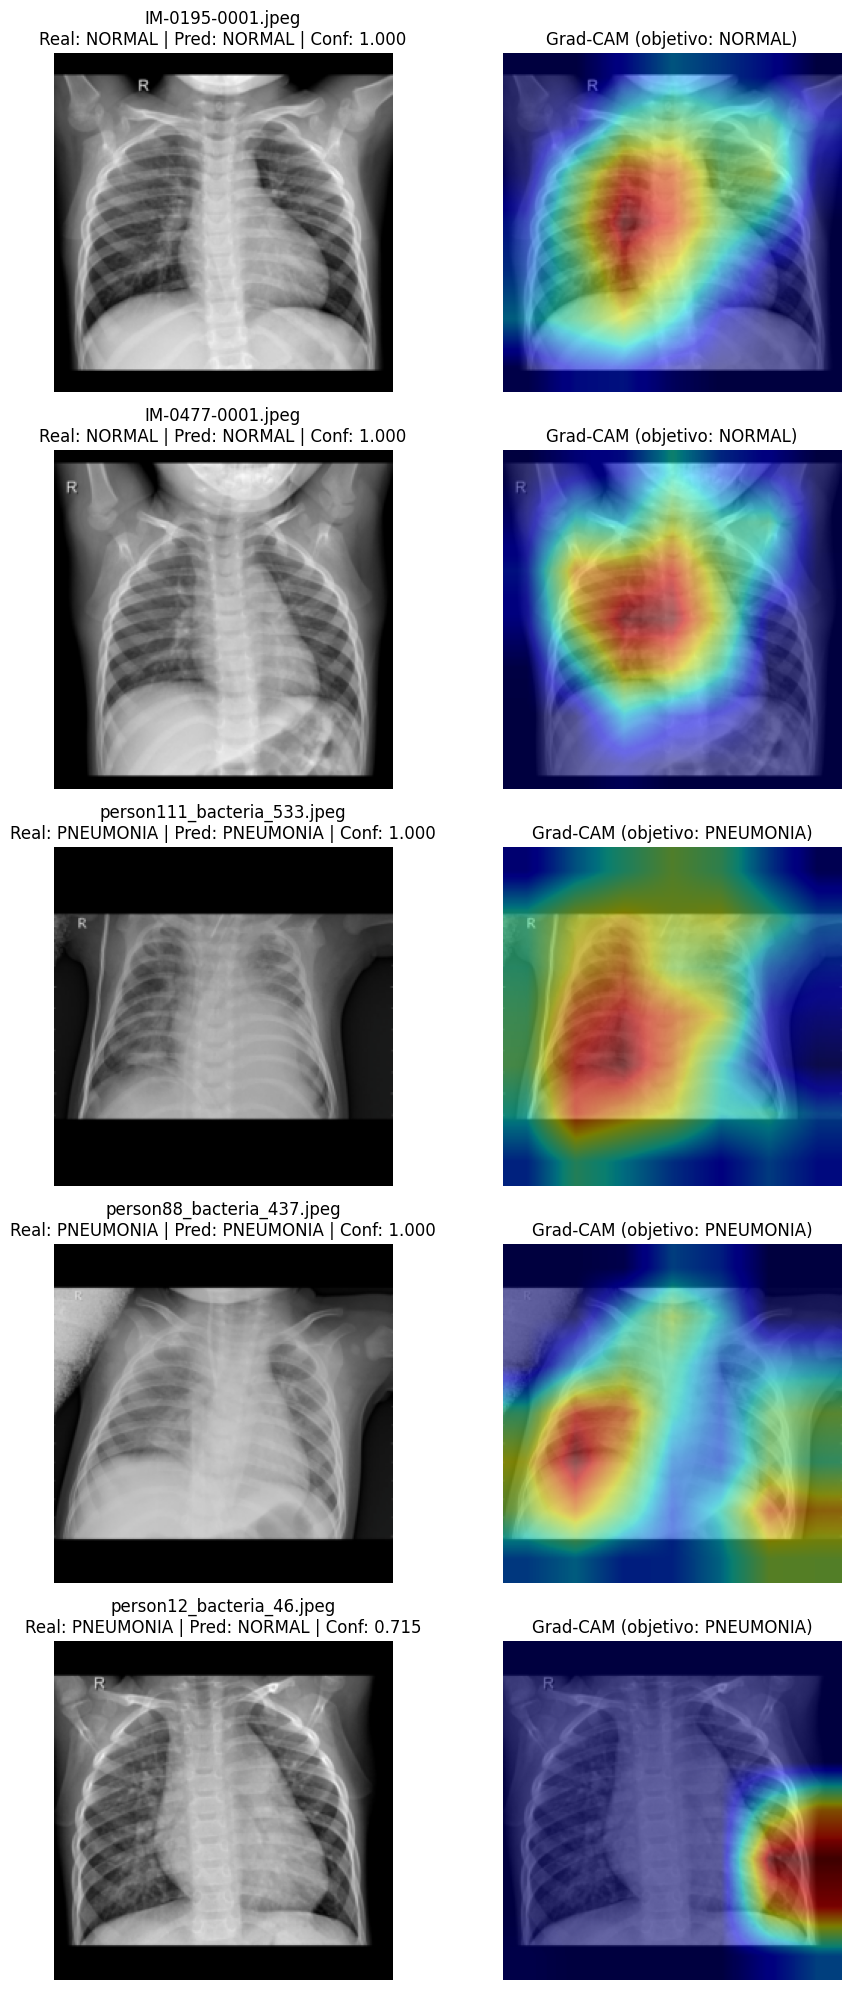


Hooks de Grad-CAM removidos. Modelo intacto.

--- Resumen de los casos analizados con Grad-CAM ---


,archivo,real,predicha,confianza,tipo
0,IM-0195-0001.jpeg,NORMAL,NORMAL,1.0000,Acierto
1,IM-0477-0001.jpeg,NORMAL,NORMAL,1.0000,Acierto
2,person111_bacteria_533.jpeg,PNEUMONIA,PNEUMONIA,0.9999,Acierto
3,person88_bacteria_437.jpeg,PNEUMONIA,PNEUMONIA,0.9998,Acierto
4,person12_bacteria_46.jpeg,PNEUMONIA,NORMAL,0.7153,Falso negativo


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# 1. Pasar el modelo a fp32 para estabilidad de gradientes en Grad-CAM
learn_optim = learn_optim.to_fp32()
learn_optim.model.eval()

# 2. Inspección rápida de la estructura del modelo para elegir la capa objetivo
print("--- Estructura del modelo (resumen) ---")
print(f"model[0] (backbone): {type(learn_optim.model[0]).__name__}")
print(f"model[1] (cabeza):   {type(learn_optim.model[1]).__name__}")
print(f"Última capa del backbone: {learn_optim.model[0][-1]}")

# Capa objetivo: última conv del backbone (último bloque residual de ResNet18)
target_layer = learn_optim.model[0][-1]

# 3. Implementación manual de Grad-CAM con hooks
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        # Registrar hooks
        self.fwd_handle = target_layer.register_forward_hook(self._save_activations)
        self.bwd_handle = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, input_tensor, class_idx):
        # Forward
        logits = self.model(input_tensor)
        # Backward sobre la clase de interés
        self.model.zero_grad()
        score = logits[:, class_idx].sum()
        score.backward()
        # Pesos = promedio espacial de los gradientes
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        # Mapa Grad-CAM = ReLU(suma ponderada de activaciones)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        # Upsample a 224x224
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        # Normalizar a [0, 1]
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, logits.detach().cpu().numpy()

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

gradcam = GradCAM(learn_optim.model, target_layer)

# 4. Selección de imágenes representativas del test
test_path = Path('/content/dataset_split/test')

# Recordamos: vocab = ['NORMAL', 'PNEUMONIA'], NORMAL=0, PNEUMONIA=1
# Reusamos test_files, preds, y_true, y_pred del Hito 7 si están vivos.
# Si no, los reconstruimos:
if 'test_files' not in dir() or 'preds' not in dir():
    from fastai.vision.all import get_image_files
    test_files = get_image_files(test_path)
    test_dl_local = learn_optim.dls.test_dl(test_files, with_labels=True)
    preds, targets = learn_optim.get_preds(dl=test_dl_local)
    y_true = targets.numpy()
    y_pred = preds.argmax(dim=1).numpy()

# Confianza de la clase predicha
confianzas = preds.max(dim=1).values.numpy()

# Construir lista de imágenes objetivo
def buscar_idx(real, pred, n, criterio_conf='alta'):
    """Busca índices con clase real y predicha dadas, ordenados por confianza."""
    mask = (y_true == real) & (y_pred == pred)
    idxs = np.where(mask)[0]
    confs = confianzas[idxs]
    orden = np.argsort(confs)[::-1] if criterio_conf == 'alta' else np.argsort(confs)
    return idxs[orden][:n]

idx_normal_ok = buscar_idx(real=0, pred=0, n=2, criterio_conf='alta')
idx_pneumonia_ok = buscar_idx(real=1, pred=1, n=2, criterio_conf='alta')
idx_fn = buscar_idx(real=1, pred=0, n=1, criterio_conf='alta')  # FN del H7

indices_seleccionados = list(idx_normal_ok) + list(idx_pneumonia_ok) + list(idx_fn)
print(f"\nImágenes seleccionadas para Grad-CAM: {len(indices_seleccionados)}")
for i in indices_seleccionados:
    print(f"  {test_files[i].name}: real={['NORMAL','PNEUMONIA'][y_true[i]]}, "
          f"pred={['NORMAL','PNEUMONIA'][y_pred[i]]}, conf={confianzas[i]:.4f}")

# 5. Generar y mostrar mapas Grad-CAM
vocab = ['NORMAL', 'PNEUMONIA']
n_imgs = len(indices_seleccionados)
fig, axes = plt.subplots(n_imgs, 2, figsize=(10, 4 * n_imgs))

for fila, i in enumerate(indices_seleccionados):
    # Cargar el batch correspondiente a esta imagen del test_dl
    test_dl_uno = learn_optim.dls.test_dl([test_files[i]], with_labels=False)
    x, = test_dl_uno.one_batch()
    x = x.requires_grad_(True)

    # Generar Grad-CAM apuntando a la clase REAL (para entender qué activa esa clase)
    clase_real = int(y_true[i])
    cam, logits = gradcam(x, class_idx=clase_real)

    # Imagen original (la del test_dl, ya preprocesada)
    img_tensor = x[0].detach().cpu()
    # Desnormalizar para visualizar
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_show = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    # Plot original
    axes[fila, 0].imshow(img_show)
    axes[fila, 0].set_title(
        f"{test_files[i].name}\n"
        f"Real: {vocab[y_true[i]]} | Pred: {vocab[y_pred[i]]} | Conf: {confianzas[i]:.3f}"
    )
    axes[fila, 0].axis('off')

    # Plot Grad-CAM superpuesto
    axes[fila, 1].imshow(img_show)
    axes[fila, 1].imshow(cam, cmap='jet', alpha=0.5)
    axes[fila, 1].set_title(f"Grad-CAM (objetivo: {vocab[clase_real]})")
    axes[fila, 1].axis('off')

plt.tight_layout()
plt.show()

# 6. Limpiar hooks
gradcam.remove()
print("\nHooks de Grad-CAM removidos. Modelo intacto.")

# 7. Resumen tabular para la conclusión
print("\n--- Resumen de los casos analizados con Grad-CAM ---")
import pandas as pd
resumen = []
for i in indices_seleccionados:
    resumen.append({
        'archivo': test_files[i].name,
        'real': vocab[int(y_true[i])],
        'predicha': vocab[int(y_pred[i])],
        'confianza': round(float(confianzas[i]), 4),
        'tipo': 'Acierto' if y_true[i] == y_pred[i] else 'Falso negativo'
    })
display(pd.DataFrame(resumen))

## Cierre del Hito 8

He aplicado Grad-CAM a cinco imágenes del test (2 NORMAL acertadas, 2 PNEUMONIA acertadas y el único falso negativo) para ver dónde está mirando el modelo cuando toma cada decisión. El resultado es revelador y obliga a revisar la lectura optimista que daban las cifras del Hito 7.

### Lo que veo en cada caso

**NORMAL acertadas (`IM-0477-0001` y `IM-0195-0001`, ambas con confianza 1.000)**: en las dos, la atención del modelo se concentra en la **silueta cardíaca y el mediastino**, no en los pulmones. Los pulmones aparecen en azul, prácticamente ignorados. El modelo está decidiendo "NORMAL" mirando el corazón y los grandes vasos centrales, no las regiones pulmonares que es donde la patología debería verse o no verse. Las dos NORMAL del test las acierta usando una región anatómica que no es la relevante para distinguir neumonía.

**PNEUMONIA acertadas (`person91_bacteria_449` y `person111_bacteria_533`, ambas con confianza > 0.99)**: aquí el comportamiento sí parece más coherente. En `person91` la atención cae en la base pulmonar inferior, una región donde la neumonía bacteriana suele provocar consolidaciones visibles. En `person111` la atención abarca la zona central-inferior del tórax, también consistente con un patrón consolidativo. **En estos dos casos sí parece que el modelo está mirando dónde toca**.

**Falso negativo (`person12_bacteria_46`, real PNEUMONIA, predicha NORMAL, confianza 0.901)**: este es el caso más serio. El mapa de calor para la clase PNEUMONIA muestra **dos focos rojos fuera del campo pulmonar útil**: uno en el borde lateral derecho y otro en el borde inferior, en zona de padding negro. El modelo está literalmente buscando la señal de "neumonía" en regiones donde no puede haberla. Como en esas zonas no hay nada que activar, el logit de PNEUMONIA queda débil y el modelo se decanta por NORMAL con alta confianza. El error no es porque la patología sea sutil; es porque el modelo está atendiendo a píxeles irrelevantes.

### Hallazgo principal

El modelo acierta el 96% del test, pero por la razón equivocada en una parte importante de los casos. Concretamente:

- En NORMAL parece estar usando **la silueta cardíaca** como predictor de "sano", no la limpieza de los campos pulmonares.
- En el falso negativo está atendiendo al **padding y los bordes** de la imagen, no a los pulmones.
- Solo en las PNEUMONIA acertadas la atención cae sobre regiones clínicamente plausibles.

Esto es un caso clásico de **modelo que aprende atajos**. Las cifras de accuracy y F1 son altas porque en el dataset actual (200 PNEUMONIA y 78 NORMAL pediátricas) esos atajos correlacionan con la clase. Pero esos atajos no son robustos: en un paciente con corazón anatómicamente normal y neumonía, el modelo va a decir NORMAL.

### Posibles causas

- **Padding negro** en el redimensionado del Hito 3. Las bandas negras introducen una región de píxeles uniformes que el modelo puede usar como referencia espacial. En el FN se ve claramente cómo la atención cae sobre esa zona.
- **Tamaño del dataset**. Con solo 222 imágenes de entrenamiento, una ResNet18 no tiene suficientes ejemplos para aprender a discriminar consolidaciones pulmonares de forma consistente. Aprende lo que funciona estadísticamente, no lo que es médicamente válido.
- **Pediatría con cajas torácicas pequeñas**: la silueta cardíaca ocupa proporcionalmente más imagen y puede dominar las activaciones.

### Implicaciones para uso clínico

El enunciado pide valorar si la solución podría servir como sistema de apoyo en un entorno clínico real. Con la información de este hito, **mi respuesta honesta es que este modelo, tal cual está, no es apto para uso clínico**, ni siquiera como apoyo. Las razones:

- Las decisiones se basan parcialmente en regiones no anatómicamente relevantes.
- El falso negativo se explica por atención al padding, no por dificultad real de la imagen.
- Un modelo clínico debe ser **robusto a perturbaciones de encuadre, padding, contraste, etc.**, y este claramente no lo es.

Como **demostración académica de un pipeline completo de visión médica con FastAI** (limpieza, split, augmentation, transfer learning, optimización, comparación de arquitecturas, evaluación, interpretabilidad), el cuaderno cumple. Como producto desplegable, no.

### Qué haría a continuación si fuera un proyecto real

- **Cambiar la estrategia de redimensionado**: probar `ResizeMethod.Crop` con recorte centrado, o un crop manual sobre el tórax si tuviera anotaciones de bounding box. Eliminar el padding para que no haya píxeles "muertos" que el modelo pueda explotar.
- **Aumentar el dataset** con miles de radiografías reales (no solo augmentadas).
- **Validar con interpretabilidad como métrica de aceptación**: pedir que en al menos el 80% de los casos la atención caiga sobre los pulmones, no solo accuracy.
- **Validación externa**: testar en un dataset de otro centro sanitario para comprobar que las regularidades aprendidas no son específicas de este origen.

### Limitación conceptual de Grad-CAM

Grad-CAM muestra **atención**, no **razonamiento**. Que el mapa de calor caiga sobre los pulmones no demuestra que el modelo "entienda" anatomía pulmonar; solo dice qué píxeles más empujan el logit. Y al revés: que caiga fuera tampoco prueba que el modelo "ignore" el resto, solo que esos píxeles concretos son los que dominan. Aun así, lo observado es lo bastante claro como para sostener las conclusiones anteriores.

**Estado activo**:
- `learn_optim` intacto, ahora en fp32 tras el Hito 8.
- Hooks de Grad-CAM removidos del modelo.
- Problema completo: 8 hitos cerrados.

Toca auditoría final del cuaderno antes de declarar la entrega lista.